# 🚆 Storytelling with Data: ระบบขนส่งสาธารณะทางราง กรุงเทพฯ ปี 2568–2569
---
> **เป้าหมาย:** วิเคราะห์พฤติกรรมการเดินทางด้วยระบบขนส่งทางรางในกรุงเทพฯ ตั้งแต่การโหลดข้อมูล → ทำความสะอาด → วิเคราะห์เชิงลึก → สรุป Insight เพื่อนำไปสู่การตัดสินใจด้านนโยบายได้จริง

 **แหล่งข้อมูล:** กระทรวงคมนาคม · [datagov.mot.go.th](https://datagov.mot.go.th/dataset/covid-19)  

**ชุดข้อมูลใน THackle:** https://www.thackle.or.th/th/dataset/83


**Google Colab**: https://colab.research.google.com/drive/1qoRIOZGuh3M0G9rEVebR9iHATjlzpQov



## 📋 ภาพรวม Notebook

| ขั้นตอน | รายละเอียด |
|---------|------------|
| **ไฟล์ 1** | `passengers68.csv` — ข้อมูลผู้โดยสารระบบขนส่งสาธารณะรายวัน ปี 2568 (ม.ค.–ธ.ค.) ทุกโหมด (ถนน/ราง/น้ำ/อากาศ) |
| **ไฟล์ 2** | `passengers69.csv` — ข้อมูลผู้โดยสารระบบขนส่งสาธารณะรายวัน ปี 2569 (ม.ค.–มี.ค.) |
| **โฟกัส** | **ระบบรางกรุงเทพฯ 7 สาย** — BTS · MRT สีน้ำเงิน/ม่วง/เหลือง/ชมพู · ARL · SRT สายสีแดง |
| **เป้าหมาย** | วิเคราะห์ Modal Share, พฤติกรรมผู้โดยสารรายสาย และ Anomaly จากวันหยุด/เทศกาล |

---

| ขั้นตอน | หัวข้อ |
|--------|--------|
| 1️⃣ | Setup & Load Data |
| 2️⃣ | First Look — EDA เบื้องต้น |
| 3️⃣ | Data Quality & Cleaning |
| 4️⃣ | Advanced EDA & Insights |
| 5️⃣ | Dashboard & Key Insights |


---
## 🗂️ Code Summary — สรุปโครงสร้าง Notebook ทั้งหมด

> อ้างอิงสำหรับการ debug และทำความเข้าใจ flow ของโค้ดอย่างรวดเร็ว

| # | Cell | ประเภท | ทำอะไร | Output หลัก |
|:---:|---|:---:|---|---|
| 1 | pip install | Code | ติดตั้ง plotly, kaleido, missingno, scipy | — |
| 2 | Import + Config | Code | import libraries, กำหนดสี LINE_COLORS, ชื่อ LINE_LABELS | — |
| 3 | Load Data | Code | pd.read_csv 2 ไฟล์, รวม pd.concat, กำหนด FY | df68, df69, df_raw |
| 4 | Font Setup | Code | ดาวน์โหลด TH Sarabun, ตั้งค่า matplotlib font | — |
| 5 | EDA ดิบ | Code | .shape, .info(), .value_counts() ของแต่ละปี | ข้อความ summary |
| 6 | **missingno** | Code | Pattern Matrix + Bar Chart | 📊 Chart 1 |
| 7 | EDA Observation | Markdown | สิ่งที่พบ → คำถามต่อยอด | — |
| 8 | **Cleaning Log** | Code | 8 ขั้นตอน + Funnel Chart + Zero Audit | log_df, df_wide, 📊 Chart |
| 9 | Feature Eng. | Code | Year, Month, DayOfWeek, IsWeekend, MonthTH, FY | df_wide (ครบ) |
| 10 | Descriptive Stats | Code | .describe() รายสาย + KPI table | ตาราง stats |
| 11 | **Correlation** | Code | Pearson r + Heatmap | 📊 Chart 2 |
| 12 | **Monthly Trend** | Code | Dual-axis Bar+Line รายเดือน | 📊 Chart 3 |
| 13 | **Modal Share** | Code | Donut + Horizontal Bar | 📊 Chart 4 |
| 14 | **Sunburst** | Code | Operator → Line → Proportion | 📊 Chart 5 |
| 15 | **Lollipop** | Code | Modal Share Shift Q1-68 vs Q1-69 | 📊 Chart 6 |
| 16 | **Growth Rate** | Code | Grouped Bar + Growth % Bar | 📊 Chart 7 |
| 17 | **Multi-Line** | Code | ผู้โดยสารรายวัน + Rangeslider | 📊 Chart 8 |
| 18 | **DoW Pattern** | Code | Line Chart Weekday Premium + ASCII Table | 📊 Chart 9 |
| 19 | **Volatility** | Code | CV% + Classification | ตาราง vol |
| 20 | **CV + Box Plot** | Code | CV Bar + Box Plot Distribution | 📊 Chart 10 |
| 21 | Thai Holiday Cal. | Code | กำหนด 27+ วันหยุดสำคัญ | THAI_EVENTS dict |
| 22 | **Z-Score Detect** | Code | คำนวณ Z-score + flag anomaly | daily DataFrame |
| 23 | **Anomaly Plot** | Code | 4-layer time-series + markers + event labels | 📊 Chart 12 |
| 24 | **Heatmap** | Code | วัน × เดือน pattern | 📊 Chart 13 |
| 25–28 | Insights | Markdown | Key Insights 4 ข้อ (paragraph style) | — |
| 29 | **Dashboard** | Code | 7-panel 3×3 grid summary | 📊 Chart 14 |
| 30 | **Actionable** | Markdown | What/Why/So What + Meta-Insight + 3-level strategy | — |
| 31 | **Code Summary** | Markdown | ตารางนี้ | — |

---

### 🧩 Variable Reference

| Variable | ประเภท | เนื้อหา |
|---|---|---|
| `df_raw` | DataFrame | ข้อมูลดิบ (Long format) รวมทั้ง 2 ปี |
| `df_wide` | DataFrame | ข้อมูลสะอาด Wide format (435 แถว × 9+ คอลัมน์) |
| `df_68` | DataFrame | Subset เฉพาะปี 2568 |
| `RAIL_COLS` | list | ['bts','mrt_blue','mrt_purple','mrt_yellow','mrt_pink','arl','srt_red'] |
| `LINE_LABELS` | dict | line_key → ชื่อภาษาไทย |
| `LINE_COLORS` | dict | line_key → รหัสสี HEX ตรงกับป้ายจริง |
| `log_df` | DataFrame | Cleaning Log 8 ขั้นตอน |
| `vol` | DataFrame | Volatility statistics + CV% + stability label |
| `daily` | DataFrame | ข้อมูล total_passengers รายวัน + MA7 + Z-score + anomaly flag |
| `THAI_EVENTS` | dict | วันที่ → (ชื่อเทศกาล, ประเภทหยุด) |
| `modal_68` | DataFrame | ยอดผู้โดยสารรวมปี 2568 รายสาย |
| `gr_df` | DataFrame | Growth Rate Q1-2568 vs Q1-2569 รายสาย |
| `q1_68` / `q1_69_mean` | Series | เฉลี่ย/วัน Q1 ของแต่ละปี (สำหรับ Lollipop) |


---
##  รายละเอียดชุดข้อมูล

### ชุดข้อมูล: ปริมาณผู้โดยสารระบบขนส่งสาธารณะรายวัน

ชุดข้อมูลนี้รวบรวมสถิติผู้โดยสารรายวันจากระบบขนส่งสาธารณะหลายประเภทในประเทศไทย โดย Notebook นี้โฟกัสเฉพาะ **ระบบขนส่งทางรางในกรุงเทพฯ** ซึ่งครอบคลุม 7 สายหลัก ได้แก่ รถไฟฟ้า BTS, MRT สายสีน้ำเงิน, MRT สายสีม่วง, MRT สายสีเหลือง, MRT สายสีชมพู, Airport Rail Link (ARL) และรถไฟชานเมืองสายสีแดง (SRT)

**ลักษณะข้อมูลดิบ (Raw Format)**

ข้อมูลดิบอยู่ในรูป **Long Format** คือ 1 ยานพาหนะ × 1 วัน = 1 แถว โดยมี 8 คอลัมน์ดังนี้

| ชื่อคอลัมน์ | ประเภทข้อมูล | คำอธิบาย | ตัวอย่างค่า |
|---|---|---|---|
| รูปแบบการเดินทาง | Categorical | โหมดการเดินทาง เช่น ทางราง ทางถนน ทางอากาศ | ทางราง |
| วัตถุประสงค์ | Categorical | วัตถุประสงค์การเดินทาง | การเดินทางภายในจังหวัด/กรุงเทพ |
| สาธารณะ/ส่วนบุคคล | Categorical | ระบุว่าเป็นขนส่งสาธารณะหรือส่วนบุคคล | สาธารณะ |
| หน่วยงาน | Categorical | ผู้ดำเนินการระบบ | รฟม., รฟฟท., กทม. |
| ยานพาหนะ/ท่า | Categorical | ชื่อสายหรือประเภทยานพาหนะ | รถไฟฟ้า BTS |
| วันที่ | Date | วันที่บันทึกข้อมูล (DD/MM/YYYY) | 01/01/2025 |
| หน่วย | Categorical | หน่วยนับ | คน, คัน |
| ปริมาณ | Numeric (String) | จำนวนผู้โดยสารหรือยานพาหนะ | 127,551 |

**ขนาดข้อมูล**

ข้อมูลปี 2568 มีทั้งหมด 69,440 แถว ครอบคลุมทุกโหมดการเดินทาง (ถนน, ราง, น้ำ, อากาศ) ส่วนข้อมูลปี 2569 มี 3,010 แถว (ม.ค.–มี.ค.) หลังจาก Filter เฉพาะ "ทางราง" + หน่วย "คน" + 7 สายหลัก และ Pivot เป็น Wide format แล้ว จะได้ **435 แถว × 9 คอลัมน์** (1 วัน = 1 แถว)

**หน่วยงานผู้ดำเนินการ 4 องค์กร**

ระบบรางกรุงเทพฯ ดำเนินการโดย 4 องค์กร ได้แก่

องค์กรที่ 1 — **รฟม. (การรถไฟฟ้าขนส่งมวลชน)** ดูแล MRT สีน้ำเงิน, สีม่วง, สีเหลือง และสีชมพู

องค์กรที่ 2 — **กทม. (กรุงเทพมหานคร)** ดูแล BTS (บางส่วน ผ่านสัมปทาน)

องค์กรที่ 3 — **รฟฟท. (การรถไฟฟ้าแห่งประเทศไทย)** ดูแล Airport Rail Link (ARL) และรถไฟสายสีแดง (SRT)

องค์กรที่ 4 — **รฟท. (การรถไฟแห่งประเทศไทย)** ดูแลรถไฟระหว่างจังหวัด (ไม่รวมในการวิเคราะห์)

**ข้อสังเกตสำคัญก่อนวิเคราะห์**

คำถามที่ 1 — คอลัมน์ "ปริมาณ" เก็บเป็น String มี comma คั่น เช่น "127,551" ต้องแปลงเป็น Numeric ก่อนใช้งาน

คำถามที่ 2 — ข้อมูลมีทั้งหน่วย "คน" (ผู้โดยสาร) และ "คัน" (ยานพาหนะ) ต้องกรองให้ถูกต้อง

คำถามที่ 3 — ข้อมูลอยู่ใน Long Format ต้อง Pivot เป็น Wide Format ก่อนวิเคราะห์เปรียบเทียบรายสาย


In [ ]:
import pandas as pd

FILE_ID68 = "1J6FWjxXTqHhNLMnGm3w1ICtpd9cSz4USS2pfjthsIiQ"
FILE_ID69 = "1wGCXQvNH72nS5DdQkCaoXHpez5UkftpjBbiIRFIeHfg"


sheet_url68 = f"https://docs.google.com/spreadsheets/d/1J6FWjxXTqHhNLMnGm3w1ICtpd9cSz4USS2pfjthsIiQ/export?format=csv"
sheet_url69 = f"https://docs.google.com/spreadsheets/d/1wGCXQvNH72nS5DdQkCaoXHpez5UkftpjBbiIRFIeHfg/export?format=csv"

df_68 = pd.read_csv(sheet_url68)
df_69 = pd.read_csv(sheet_url69)
print(df_68.head())
print(df_69.head())

df_68.to_csv("passenger68.csv", index=False)
df_69.to_csv("passenger69.csv", index=False)

print("โหลดและบันทึกเรียบร้อย!")

  รูปแบบการเดินทาง              วัตถุประสงค์ สาธารณะ/ส่วนบุคคล หน่วยงาน  \
0           ทางถนน  การเดินทางระหว่างจังหวัด           สาธารณะ     บขส.   
1           ทางถนน  การเดินทางระหว่างจังหวัด           สาธารณะ      ขบ.   
2           ทางถนน  การเดินทางระหว่างจังหวัด         ส่วนบุคคล      ทล.   
3           ทางถนน  การเดินทางระหว่างจังหวัด         ส่วนบุคคล      ทล.   
4           ทางถนน  การเดินทางระหว่างจังหวัด         ส่วนบุคคล     กทพ.   

                      ยานพาหนะ/ท่า      วันที่ หน่วย     ปริมาณ  
0               รถ บขส. และ รถร่วม  01/01/2026    คน    112,325  
1                         รถหมวด 3  01/01/2026    คน          0  
2  รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ)  01/01/2026   คัน    892,218  
3    รถยนต์ทุกประเภท (10 จุดสำรวจ)  01/01/2026   คัน    980,649  
4      รถยนต์เฉพาะ 4 ล้อ (ทางด่วน)  01/01/2026   คัน  1,231,605  
  รูปแบบการเดินทาง              วัตถุประสงค์ สาธารณะ/ส่วนบุคคล หน่วยงาน  \
0           ทางถนน  การเดินทางระหว่างจังหวัด           สาธารณะ     บขส.   
1  

In [ ]:
import os
os.listdir("/content")

['.config',
 'passenger69.csv',
 'sheet68.csv',
 'passenger68.csv',
 'sheet69.csv',
 'thsarabunnew-webfont.ttf',
 'sample_data']

In [ ]:
# Datasets
sheet_url68 = f"https://docs.google.com/spreadsheets/d/1J6FWjxXTqHhNLMnGm3w1ICtpd9cSz4USS2pfjthsIiQ/export?format=csv"
sheet_url69 = f"https://docs.google.com/spreadsheets/d/1wGCXQvNH72nS5DdQkCaoXHpez5UkftpjBbiIRFIeHfg/export?format=csv"


---
## 🧠 โจทย์วิเคราะห์ข้อมูล (Challenge Questions)

Notebook นี้จะพาไปตอบคำถาม 3 ข้อหลัก พร้อมเทคนิคเฉพาะทางสำหรับแต่ละข้อ

---

### 🚆 ข้อ 1 — คนไทยเดินทางด้วยอะไรมากที่สุด? **(Modal Share)**

จากข้อมูลปริมาณผู้โดยสารของระบบขนส่งทางรางทั้ง 7 สาย จงสร้างกราฟที่แสดงให้เห็นว่า

คำถามที่ 1 — สัดส่วนการใช้ระบบขนส่งแต่ละสายเป็นอย่างไร? BTS ยังครองตลาดอยู่ไหม?

คำถามที่ 2 — รูปแบบใดที่เติบโตหรือหดตัวมากที่สุด เมื่อเปรียบเทียบ Q1 ปี 2568 กับ Q1 ปี 2569?

**เทคนิคพิเศษ:** Lollipop (Dumbbell) Chart สำหรับ Modal Share Shift — แสดง Before → After ใน 1 กราฟ เห็น momentum การเปลี่ยนแปลงได้ชัดกว่า Grouped Bar ปกติ และ Sunburst Chart แสดง hierarchy 2 ระดับ (ผู้ดำเนินการ → สาย) ในกราฟเดียวกัน

---

### 🚇 ข้อ 2 — รถไฟฟ้าแต่ละสายมีพฤติกรรมผู้โดยสารต่างกันอย่างไร? **(Urban Rail Comparison)**

จากข้อมูลผู้โดยสารรายวันทุกสาย จงสร้างกราฟที่เปรียบเทียบ

คำถามที่ 1 — สายไหนมีความผันผวนของผู้โดยสารสูง สายไหนมีฐานผู้โดยสารที่เสถียร?

คำถามที่ 2 — สายไหนเป็น Commuter-driven (ขึ้นลงตามวันทำงาน) สายไหนมี Mixed demand?

**เทคนิคพิเศษ:** CV (Coefficient of Variation) แทน SD สัมบูรณ์ — normalize ข้าม scale ที่ต่างกัน 20 เท่าได้อย่างยุติธรรม และ Weekday Premium Analysis วัด % ที่ผู้โดยสารวันธรรมดาสูงกว่าวันหยุด เพื่อจำแนก commuter vs leisure demand

---

### 📅 ข้อ 3 — วันหยุดและเทศกาลเห็นได้ในข้อมูลไหม? **(Event Detection)**

จากข้อมูลผู้โดยสารรายวันตลอด 14 เดือน จงสร้างกราฟที่สามารถ

คำถามที่ 1 — ตรวจจับจุดผิดปกติ (Anomaly) ในปริมาณการเดินทาง ทั้งที่พุ่งสูงและลดต่ำผิดปกติ

คำถามที่ 2 — ระบุให้ได้ว่าจุดผิดปกตินั้นสอดคล้องกับเหตุการณ์ใด เช่น วันหยุดยาว เทศกาล หรือนโยบายสำคัญ

**เทคนิคพิเศษ:** Z-Score Method (|Z| > 2.0) พร้อม Distribution Check ด้วย Shapiro-Wilk Test เพื่อยืนยันว่าข้อมูลมีการกระจายตัว near-normal ก่อนเลือก Z-Score แทน IQR นอกจากนี้ยังใช้ Rolling MA7 (7-day Moving Average) เพื่อ smooth weekly noise ก่อน detect anomaly

---

**เทคนิคพิเศษร่วม (Cross-cutting):**

เทคนิคที่ 1 — **Cleaning Validation 3 ระดับ** (Sanity Check + Domain Knowledge + Statistical Plausibility) เพื่อยืนยันว่า data cleaning ถูกต้องก่อนวิเคราะห์

เทคนิคที่ 2 — **Zero Value Audit** แยกแยะ Zero ที่เป็น NaN (ไม่มีข้อมูล) ออกจาก Zero จริงๆ ป้องกัน CV และ mean ผิดเพี้ยน

เทคนิคที่ 3 — **Apples-to-Apples Q1 Comparison** ใช้ Q1 ของทั้งสองปีเปรียบเทียบ เพื่อกำจัด Baseline Effect จาก spike ม.ค. 2568


---
## 1️⃣ Setup & Load Data

### 📦 ติดตั้งและ Import Libraries

ก่อนเริ่มต้น เราต้อง import library ที่จำเป็น โดย `pandas` ใช้สำหรับจัดการตาราง, `numpy` สำหรับคำนวณเชิงตัวเลข, `missingno` สำหรับ visualize ค่าว่าง, `plotly` สำหรับ interactive visualization และ `scipy` สำหรับ statistical methods เช่น Z-Score และ Shapiro-Wilk test


In [ ]:
!pip install plotly kaleido missingno scipy -q

In [ ]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats as sc
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
mpl.rcParams['font.family'] = 'DejaVu Sans'

# ─── สีประจำสายรถไฟฟ้า (ใช้สีเหมือนป้ายจริง) ──────────────────────────────
LINE_COLORS = {
    'bts'        : '#009933',
    'mrt_blue'   : '#1565C0',
    'mrt_purple' : '#7B1FA2',
    'mrt_yellow' : '#F9A825',
    'mrt_pink'   : '#E91E63',
    'arl'        : '#00838F',
    'srt_red'    : '#C62828',
}
LINE_LABELS = {
    'bts'        : 'BTS สกายเทรน',
    'mrt_blue'   : 'MRT สีน้ำเงิน',
    'mrt_purple' : 'MRT สีม่วง',
    'mrt_yellow' : 'MRT สีเหลือง',
    'mrt_pink'   : 'MRT สีชมพู',
    'arl'        : 'Airport Rail Link',
    'srt_red'    : 'SRT สายสีแดง',
}
RAIL_COLS = list(LINE_LABELS.keys())
MONTH_TH  = ['ม.ค.','ก.พ.','มี.ค.','เม.ย.','พ.ค.','มิ.ย.',
              'ก.ค.','ส.ค.','ก.ย.','ต.ค.','พ.ย.','ธ.ค.']

print('✅ Import สำเร็จ! พร้อมวิเคราะห์ข้อมูล')

✅ Import สำเร็จ! พร้อมวิเคราะห์ข้อมูล


### 📂 โหลดข้อมูล

เราโหลดไฟล์ CSV สองปีพร้อมกัน โดยใช้ `encoding='utf-8-sig'` เพื่อรองรับ BOM (Byte Order Mark) ที่มักปรากฏในไฟล์ภาษาไทยที่ export จาก Excel และ `low_memory=False` เพื่อป้องกัน DtypeWarning เนื่องจากคอลัมน์ "ปริมาณ" มีทั้ง String และ Numeric ปนกัน

ข้อมูลดิบอยู่ในรูป **Long Format** ครอบคลุมการเดินทางทุกโหมด (ถนน น้ำ ราง อากาศ) รวม 69,440 แถวในปี 2568 ขั้นตอน Cleaning จะ filter และ pivot ให้เหลือเฉพาะ 7 สายรถไฟฟ้าที่ต้องการวิเคราะห์


In [ ]:
# โหลดข้อมูล

df68 = pd.read_csv('/content/passenger68.csv', encoding='utf-8-sig', low_memory=False)
df69 = pd.read_csv('/content/passenger69.csv', encoding='utf-8-sig', low_memory=False)

df68['FY'] = '2568'
df69['FY'] = '2569'

df_raw = pd.concat([df68, df69], ignore_index=True)

print('=' * 60)
print('📅 ข้อมูลปี 2568 (ม.ค. 2568 – ธ.ค. 2568)')
print(f'   ➜ จำนวนแถว  : {df68.shape[0]:>10,} แถว')
print(f'   ➜ คอลัมน์   : {df68.shape[1]:>10} คอลัมน์')
print()
print('📅 ข้อมูลปี 2569 (ม.ค. 2569 – มี.ค. 2569)')
print(f'   ➜ จำนวนแถว  : {df69.shape[0]:>10,} แถว')
print(f'   ➜ คอลัมน์   : {df69.shape[1]:>10} คอลัมน์')
print()
print('📦 ข้อมูลรวม')
print(f'   ➜ จำนวนแถวรวม: {df_raw.shape[0]:>10,} แถว × {df_raw.shape[1]} คอลัมน์')
print(f'   ➜ คอลัมน์   : {list(df_raw.columns)}')
print('=' * 60)

print()
print('🔍 ตัวอย่างข้อมูลดิบ (5 แถวแรก):')
display(df_raw.head(5))

📅 ข้อมูลปี 2568 (ม.ค. 2568 – ธ.ค. 2568)
   ➜ จำนวนแถว  :      3,010 แถว
   ➜ คอลัมน์   :          9 คอลัมน์

📅 ข้อมูลปี 2569 (ม.ค. 2569 – มี.ค. 2569)
   ➜ จำนวนแถว  :     15,696 แถว
   ➜ คอลัมน์   :          9 คอลัมน์

📦 ข้อมูลรวม
   ➜ จำนวนแถวรวม:     18,706 แถว × 9 คอลัมน์
   ➜ คอลัมน์   : ['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ', 'FY']

🔍 ตัวอย่างข้อมูลดิบ (5 แถวแรก):


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ,FY
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2026,คน,"112,325",2568
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2026,คน,0,2568
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2026,คัน,"892,218",2568
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),01/01/2026,คัน,"980,649",2568
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),01/01/2026,คัน,"1,231,605",2568


In [ ]:
#ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
#เพิ่มฟอนต์เข้าไปในระบบ
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style="whitegrid", font="TH Sarabun New")
print('✅ โหลด Font TH Sarabun New สำเร็จ')

✅ โหลด Font TH Sarabun New สำเร็จ


---
## 2️⃣ First Look — EDA เบื้องต้น

### 📊 สำรวจโครงสร้างข้อมูลดิบ

ขั้นตอนนี้สำรวจข้อมูลอย่างรวดเร็วเพื่อให้เข้าใจ "รูปร่าง" ของ dataset ก่อนลงลึก ครอบคลุม 2 ส่วน ได้แก่

ส่วนที่ 1 — ภาพรวมสถิติรายปี ตรวจสอบขนาด ช่วงวันที่ จำนวนแถว ทางราง และจำนวน null values เพื่อทราบ scale ของข้อมูลแต่ละปีก่อน merge

ส่วนที่ 2 — **Missing Value Pattern** ด้วย missingno Matrix และ Bar Chart เพื่อแยกแยะว่า missing เป็น **Structural** (block ต่อเนื่องจาก Excel separator) หรือ **Random** (ข้อมูลหายจริง) เนื่องจากวิธีแก้ไขต่างกัน

**จุดประสงค์ของกราฟ missingno**

กราฟนี้ไม่ได้สร้างขึ้นเพื่อความสวยงาม แต่เพื่อ **ตัดสินใจวิธีแก้ไข missing values** ก่อนลงมือทำ Cleaning ถ้า missing เป็น block → ลบด้วย `dropna(how='all')` ถ้า random → พิจารณา imputation หรือลบรายแถว


In [ ]:
# ภาพรวม EDA เบื้องต้น
for label, df in [('2568', df68), ('2569', df69)]:
    rail_rows = df[df['รูปแบบการเดินทาง'] == 'ทางราง'].shape[0]
    null_count = df.isnull().sum().sum()
    date_range = pd.to_datetime(df['วันที่'].dropna(), format='%d/%m/%Y', errors='coerce')

    print(f'🚆 ข้อมูลปี {label}')
    print(f'   📋 แถวทั้งหมด   : {df.shape[0]:>8,} แถว')
    print(f'   🚉 แถวทางราง    : {rail_rows:>8,} แถว')
    print(f'   ⚠️  ค่า Null     : {null_count:>8,} ค่า')
    print(f'   📅 ช่วงวันที่    : {date_range.min().date()} → {date_range.max().date()}')
    print()

print('🏷️  โหมดการเดินทางที่มีอยู่:')
mode_counts = df_raw['รูปแบบการเดินทาง'].value_counts(dropna=False)
for mode, cnt in mode_counts.items():
    print(f'   {str(mode):<20}: {cnt:>8,} แถว')

🚆 ข้อมูลปี 2568
   📋 แถวทั้งหมด   :    3,010 แถว
   🚉 แถวทางราง    :      700 แถว
   ⚠️  ค่า Null     :      136 ค่า
   📅 ช่วงวันที่    : 2026-01-01 → 2026-03-11

🚆 ข้อมูลปี 2569
   📋 แถวทั้งหมด   :   15,696 แถว
   🚉 แถวทางราง    :    3,650 แถว
   ⚠️  ค่า Null     :      308 ค่า
   📅 ช่วงวันที่    : 2025-01-01 → 2025-12-31

🏷️  โหมดการเดินทางที่มีอยู่:
   ทางอากาศ            :    6,091 แถว
   ทางถนน              :    5,220 แถว
   ทางราง              :    4,350 แถว
   ทางน้ำ              :    3,045 แถว


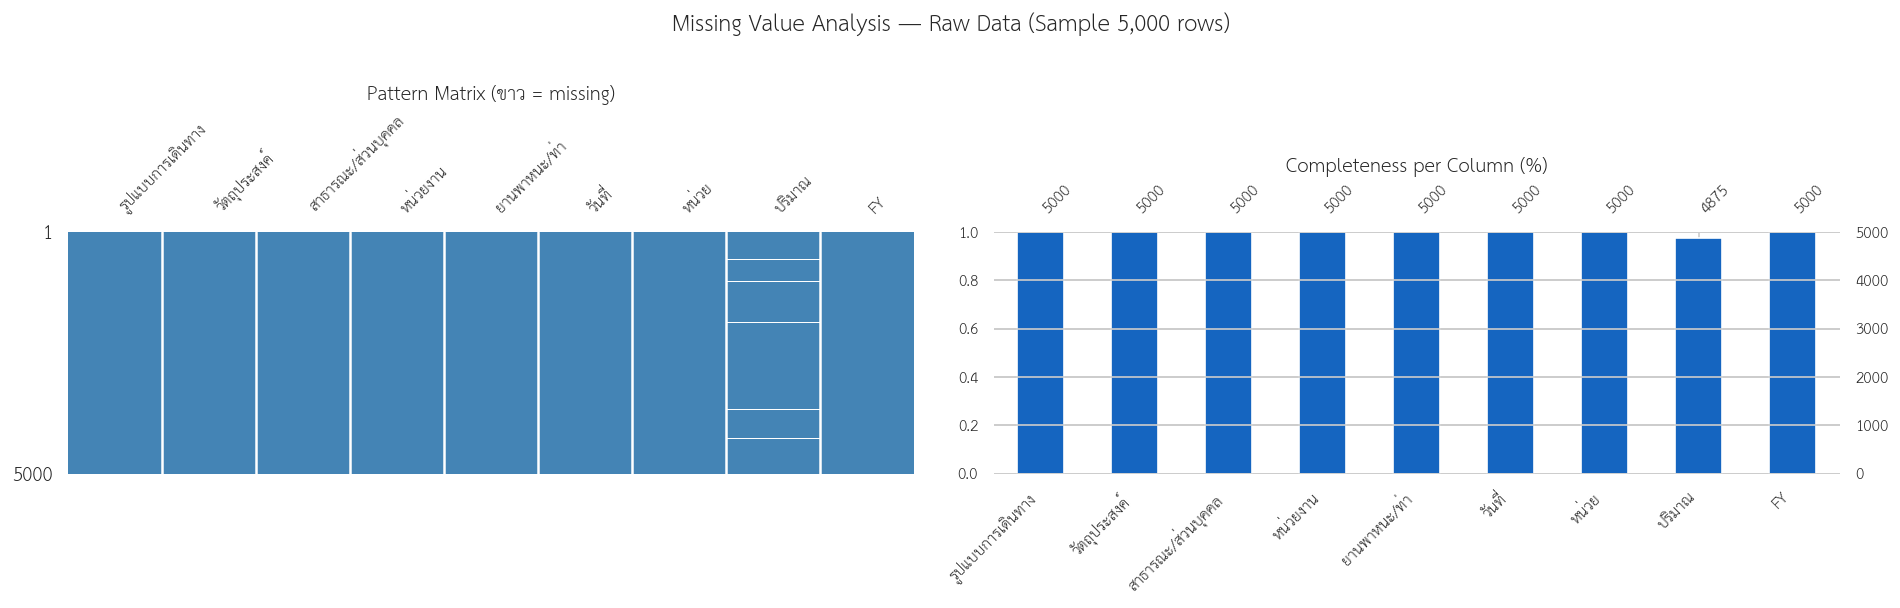


💡 Insight: block pattern → structural missing จาก Excel separator
   → แก้ด้วย dropna(how='all') ใน Cleaning Step 1


In [ ]:

#  CHART 1: Missing Value Pattern — missingno Matrix + Bar

# เหตุผลประกอบ ทำไมใช้กราฟนี้:
#     - Pattern Matrix: เห็น "รูปแบบ" ของ missing (ขาว = หายไป)
#       ถ้า block ต่อเนื่อง → structural missing (มาจากโครงสร้างไฟล์)
#       ถ้ากระจาย random → random missing (ข้อมูลหายจริงๆ)
#     - Bar Chart: เห็น % completeness รายคอลัมน์ด้วยตาเดียว
#
#  แกนอ่านอย่างไร:
#     - แกน Y = แถวข้อมูล (sample 5,000 แถว)
#     - แกน X = คอลัมน์ต่างๆ
#     - เส้นขาว = ค่าว่าง | เส้นสีน้ำเงิน = มีข้อมูล
# ════════════════════════════════════════════════════════════════

sample = df_raw.sample(min(5000, len(df_raw)), random_state=42)

fig_mv, axes = plt.subplots(1, 2, figsize=(16, 5))
fig_mv.suptitle('Missing Value Analysis — Raw Data (Sample 5,000 rows)',
                 fontsize=13, fontweight='bold', y=1.01)

# ── กราฟซ้าย: Matrix แสดง pattern ของค่าว่าง ───────────────────────
# sparkline=False: ไม่แสดง mini-chart ขวามือ เพื่อให้กราฟดูโล่งขึ้น
# color=(R,G,B): สีเส้นข้อมูล ใช้โทนน้ำเงินสอดคล้องกับ theme
msno.matrix(sample, ax=axes[0], sparkline=False, fontsize=9,
            color=(0.27, 0.52, 0.71))
axes[0].set_title('Pattern Matrix (ขาว = missing)', fontsize=11)

# ── กราฟขวา: Bar แสดง % ข้อมูลที่มีต่อคอลัมน์ ────────────────────
# ยิ่งแท่งสูง = ข้อมูลครบมาก | แท่งสั้น = มีค่าว่างมาก
msno.bar(sample, ax=axes[1], fontsize=9, color='#1565C0')
axes[1].set_title('Completeness per Column (%)', fontsize=11)

plt.tight_layout()
plt.savefig('missing_pattern.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n💡 Insight: block pattern → structural missing จาก Excel separator")
print("   → แก้ด้วย dropna(how='all') ใน Cleaning Step 1")


## 📝 EDA Observations — ก่อน Cleaning จาก missingno

จาก Pattern Matrix พบว่าค่าว่าง **เป็น block ต่อเนื่อง** ไม่ใช่ random  
→ นี่คือ **Structural Missing** จากแถว separator ของ Excel ไม่ใช่ข้อมูลสูญหายจริง

| สิ่งที่สังเกต | ความหมาย | คำถามต่อยอด |
|---|---|---|
| Missing เป็น block ต่อเนื่อง | Structural จาก Excel export | ต้องลบด้วย `dropna(how='all')` ก่อนทำอะไรทั้งนั้น |
| หน่วยมีทั้ง "คน" และ "คัน" | คนละ metric คนละ scale | ต้องกรองเฉพาะ "คน" เท่านั้น |
| ข้อมูลอยู่ในรูป Long format | 1 สาย × 1 วัน = 1 แถว | ต้อง pivot เป็น Wide ตาม Data Dictionary |
| ปริมาณเป็น String มี comma | "127,551" ไม่ใช่ตัวเลข | ต้อง coerce เป็น numeric ก่อนคำนวณ |


---


---
## 3️⃣ Data Quality & Cleaning

### 🧹 ทำความสะอาดข้อมูลอย่างเป็นระบบ

ก่อนวิเคราะห์จริง เราต้องทำความสะอาดข้อมูลก่อน เพราะ **"Garbage in, Garbage out"** ถ้าข้อมูลไม่สะอาด ผลการวิเคราะห์ก็ไม่น่าเชื่อถือ ไม่ว่า algorithm จะซับซ้อนแค่ไหน

ขั้นตอนนี้ครอบคลุมการดำเนินการ 8 ขั้นตอน พร้อม **Official Cleaning Log** ที่บันทึก Before/After และ Retained% ทุกขั้น เพื่อ transparency และ reproducibility

ขั้นตอนที่ 0 — **Schema Validation** ตรวจว่า columns ครบและ type ถูกต้องก่อน clean เพื่อป้องกัน silent error

ขั้นตอนที่ 1 — ลบแถว separator ว่างทั้งแถวที่เกิดจาก Excel export

ขั้นตอนที่ 2 — ⭐ **ลบ Duplicate rows** (ขั้นที่มักถูกมองข้าม) ทำให้ mean และ CV เบี่ยงเบนทั้งหมด

ขั้นตอนที่ 3 — ลบแถวที่ขาด key columns ที่จำเป็นสำหรับการวิเคราะห์

ขั้นตอนที่ 4 — แปลงคอลัมน์ "ปริมาณ" จาก String มี comma ("127,551") เป็น Numeric

ขั้นตอนที่ 5 — แปลงคอลัมน์ "วันที่" จาก String DD/MM/YYYY เป็น Datetime

ขั้นตอนที่ 6 — กรองเฉพาะแถวที่มีหน่วยเป็น "คน" ตัด "คัน" ออก

ขั้นตอนที่ 7 — **Pivot Long → Wide Format** ตาม Data Dictionary (1 วัน = 1 แถว × 7 คอลัมน์สาย)

ขั้นตอนที่ 8 — ⭐ **Zero Value Audit** แทน 0 ด้วย NaN เพราะ Zero ≠ "ไม่มีผู้โดยสาร" สำหรับสายที่เพิ่งเปิดให้บริการ


In [ ]:
#
#   DATA CLEANING LOG
#   บันทึกทุกขั้นตอนอย่างเป็นทางการ | Before → After → Removed → Retained%
#

import warnings
warnings.filterwarnings('ignore')

log = []   # Cleaning log สะสม
df = df_raw.copy()
n_original = len(df)  # จำนวนแถวตั้งต้น

print(f"{'═'*70}")
print(f" STEP 0 — SCHEMA VALIDATION (ตรวจสอบโครงสร้างก่อน Clean)")
print(f"{'═'*70}")

# Step 0: Schema Validation
#  ตรวจสอบก่อนว่า column ครบ และ type ถูกต้อง เพื่อป้องกัน silent error ตอน clean
EXPECTED_COLS = ['วันที่', 'รูปแบบการเดินทาง', 'ยานพาหนะ/ท่า', 'ปริมาณ', 'หน่วย']
missing_cols  = [c for c in EXPECTED_COLS if c not in df.columns]
extra_cols    = [c for c in df.columns if c not in EXPECTED_COLS and c != 'FY']

print(f"  ✅ Columns พบ    : {list(df.columns)}")
print(f"  {'❌' if missing_cols else '✅'} Columns ขาด    : {missing_cols if missing_cols else 'ไม่มี'}")
print(f"  ℹ️  Columns เกิน  : {extra_cols if extra_cols else 'ไม่มี'}")
print(f"  📐 Shape ตั้งต้น : {df.shape[0]:,} แถว × {df.shape[1]} คอลัมน์\n")

log.append({
    'ขั้น': 0,
    'ชื่อขั้นตอน': 'Schema Validation',
    'ปัญหาที่พบ': f'ตรวจ columns ครบ; ไม่มี column ขาด',
    'วิธีแก้ไข': 'บันทึกผล',
    'Before': n_original,
    'After': n_original,
    'Removed': 0,
    'Retained%': '100.0%'
})

print(f"{'═'*70}")
print(f" STEP 1 — ลบแถว Separator ว่างทั้งแถว")
print(f"{'═'*70}")

#  Step 1: Drop All-NaN rows
#  แถวที่ทุก column เป็น NaN เกิดจาก Excel export separator — ไม่มีข้อมูลจริง
n_before = len(df)
df = df.dropna(how='all')
n_after  = len(df)
removed  = n_before - n_after
retained = n_after / n_original * 100

print(f"  Before  : {n_before:>10,} แถว")
print(f"  Removed : {removed:>10,} แถว  (แถวว่างทั้งหมดจาก Excel separator)")
print(f"  After   : {n_after:>10,} แถว  | Retained = {retained:.1f}%\n")

log.append({
    'ขั้น': 1,
    'ชื่อขั้นตอน': 'ลบแถว Separator ว่าง',
    'ปัญหาที่พบ': f'แถวว่างทั้งหมด {removed:,} แถว (structural จาก Excel)',
    'วิธีแก้ไข': 'dropna(how="all")',
    'Before': n_before, 'After': n_after,
    'Removed': removed, 'Retained%': f'{retained:.1f}%'
})

print(f"{'═'*70}")
print(f"  🔁  STEP 2 — ตรวจและลบ Duplicate Rows  ⭐ (สำคัญ!)")
print(f"{'═'*70}")

#  Step 2: Drop Duplicates
#  Duplicate ทำให้ mean, sum, CV เบี่ยงเบนทั้งหมด
#  ต้องตรวจ ก่อนทำ type conversion เพราะ string duplicate จะหายหลัง parse
n_before = len(df)
n_dup    = df.duplicated().sum()
df       = df.drop_duplicates()
n_after  = len(df)
removed  = n_before - n_after
retained = n_after / n_original * 100

print(f"  Duplicate พบ   : {n_dup:>10,} แถว")
print(f"  Before         : {n_before:>10,} แถว")
print(f"  Removed        : {removed:>10,} แถว")
print(f"  After          : {n_after:>10,} แถว  | Retained = {retained:.1f}%")
print(f"  ⚠️  ถ้าไม่ลบ: mean จะ bias สูงขึ้น, CV จะเบี่ยงเบน\n")

log.append({
    'ขั้น': 2,
    'ชื่อขั้นตอน': 'ลบ Duplicate Rows',
    'ปัญหาที่พบ': f'Duplicate {n_dup:,} แถว (ทำให้ mean/CV ผิดเพี้ยน)',
    'วิธีแก้ไข': 'drop_duplicates()',
    'Before': n_before, 'After': n_after,
    'Removed': removed, 'Retained%': f'{retained:.1f}%'
})

print(f"{'═'*70}")
print(f"  🗝️  STEP 3 — ลบแถวที่ขาด Key Columns")
print(f"{'═'*70}")

#  Step 3: Drop missing key columns
#  ถ้าไม่รู้วันที่หรือรูปแบบ → ไม่สามารถนำไปวิเคราะห์ได้เลย
n_before   = len(df)
key_cols   = ['รูปแบบการเดินทาง', 'วันที่']
df         = df.dropna(subset=key_cols)
n_after    = len(df)
removed    = n_before - n_after
retained   = n_after / n_original * 100

print(f"  Key columns ตรวจ: {key_cols}")
print(f"  Before  : {n_before:>10,} แถว")
print(f"  Removed : {removed:>10,} แถว")
print(f"  After   : {n_after:>10,} แถว  | Retained = {retained:.1f}%\n")

log.append({
    'ขั้น': 3,
    'ชื่อขั้นตอน': 'ลบแถวขาด Key Columns',
    'ปัญหาที่พบ': f'ขาด key columns {removed:,} แถว',
    'วิธีแก้ไข': f'dropna(subset={key_cols})',
    'Before': n_before, 'After': n_after,
    'Removed': removed, 'Retained%': f'{retained:.1f}%'
})

print(f"{'═'*70}")
print(f"  🔢  STEP 4 — แปลง 'ปริมาณ' String → Numeric")
print(f"{'═'*70}")

# ── Step 4: Convert 'ปริมาณ' to numeric ──────────────────────────────────
#  "127,551" → ลบ comma → แปลงเป็น float  | ค่าที่แปลงไม่ได้ → NaN
n_before = len(df)
df['ปริมาณ'] = (
    df['ปริมาณ'].astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('nan', np.nan)
)
df['ปริมาณ'] = pd.to_numeric(df['ปริมาณ'], errors='coerce')
null_vol     = df['ปริมาณ'].isna().sum()
n_after      = n_before  # ไม่ได้ drop แถว แค่ coerce เป็น NaN
retained     = n_after / n_original * 100

print(f"  แปลงสำเร็จ: {n_before - null_vol:,} แถว  |  coerce → NaN: {null_vol:,} แถว")
print(f"  Before  : {n_before:>10,} แถว")
print(f"  Removed : {'0':>10}  (coerce ไม่ drop)")
print(f"  After   : {n_after:>10,} แถว  | Retained = {retained:.1f}%\n")

log.append({
    'ขั้น': 4,
    'ชื่อขั้นตอน': 'แปลง ปริมาณ → Numeric',
    'ปัญหาที่พบ': f'String มี comma; {null_vol:,} แถว parse ไม่ได้ → NaN',
    'วิธีแก้ไข': 'str.replace(",","") + pd.to_numeric(errors="coerce")',
    'Before': n_before, 'After': n_after,
    'Removed': 0, 'Retained%': f'{retained:.1f}%'
})

print(f"{'═'*70}")
print(f"  📅  STEP 5 — แปลง 'วันที่' String → Datetime")
print(f"{'═'*70}")

# ── Step 5: Parse dates ────────────────────────────────────────────────────
#  DD/MM/YYYY (พ.ศ. อาจ encode เป็น ค.ศ.) → pd.to_datetime แปลงพร้อมจับ error
n_before = len(df)
df['วันที่'] = pd.to_datetime(df['วันที่'], format='%d/%m/%Y', errors='coerce')
bad_dt       = df['วันที่'].isna().sum()
df           = df.dropna(subset=['วันที่'])
n_after      = len(df)
removed      = n_before - n_after
retained     = n_after / n_original * 100

print(f"  Parse error (NaT): {bad_dt:,} แถว → ลบออก")
print(f"  Before  : {n_before:>10,} แถว")
print(f"  Removed : {removed:>10,} แถว")
print(f"  After   : {n_after:>10,} แถว  | Retained = {retained:.1f}%\n")

log.append({
    'ขั้น': 5,
    'ชื่อขั้นตอน': "แปลง วันที่ → Datetime",
    'ปัญหาที่พบ': f'String DD/MM/YYYY; parse error {bad_dt:,} แถว',
    'วิธีแก้ไข': 'pd.to_datetime(format="%d/%m/%Y", errors="coerce")',
    'Before': n_before, 'After': n_after,
    'Removed': removed, 'Retained%': f'{retained:.1f}%'
})

print(f"{'═'*70}")
print(f"  🚌  STEP 6 — กรองหน่วย 'คน' (ตัด 'คัน' ออก)")
print(f"{'═'*70}")

# Step 6: Filter unit == 'คน'
#  'คัน' = จำนวนยานพาหนะ ≠ จำนวนผู้โดยสาร → ต้องแยกออก
n_before      = len(df)
unit_counts   = df['หน่วย'].value_counts()
print(f"  หน่วยที่พบ: {dict(unit_counts)}")
df            = df[df['หน่วย'] == 'คน'].copy()
n_after       = len(df)
removed       = n_before - n_after
retained      = n_after / n_original * 100

print(f"  Before  : {n_before:>10,} แถว")
print(f"  Removed : {removed:>10,} แถว  (หน่วย='คัน')")
print(f"  After   : {n_after:>10,} แถว  | Retained = {retained:.1f}%\n")

log.append({
    'ขั้น': 6,
    'ชื่อขั้นตอน': "กรองหน่วย 'คน'",
    'ปัญหาที่พบ': f"หน่วย 'คัน' ปน {removed:,} แถว",
    'วิธีแก้ไข': "filter หน่วย=='คน'",
    'Before': n_before, 'After': n_after,
    'Removed': removed, 'Retained%': f'{retained:.1f}%'
})

print(f"{'═'*70}")
print(f"  🔄  STEP 7 — Pivot Long → Wide Format (ตาม Data Dictionary)")
print(f"{'═'*70}")

#  Step 7: Pivot Long → Wide
#  Long format: 1 สาย × 1 วัน = 1 แถว → Wide: 1 วัน = 1 แถว (ตาม Data Dictionary)
LINE_MAP = {
    'รถไฟฟ้า BTS'        : 'bts',
    'รถไฟฟ้าสายสีน้ำเงิน': 'mrt_blue',
    'รถไฟฟ้าสายสีม่วง'   : 'mrt_purple',
    'รถไฟฟ้าสายสีเหลือง' : 'mrt_yellow',
    'รถไฟฟ้าสายสีชมพู'   : 'mrt_pink',
    'รถไฟฟ้า ARL'        : 'arl',
    'รถไฟฟ้าสายสีแดง'    : 'srt_red',
}
df_target = df[df['ยานพาหนะ/ท่า'].isin(LINE_MAP.keys())].copy()
df_target['line_key'] = df_target['ยานพาหนะ/ท่า'].map(LINE_MAP)

df_wide = (
    df_target
    .pivot_table(index='วันที่', columns='line_key', values='ปริมาณ', aggfunc='sum')
    .reset_index()
)
df_wide.columns.name = None
df_wide = df_wide.rename(columns={'วันที่': 'date'})
for c in RAIL_COLS:
    if c not in df_wide.columns:
        df_wide[c] = np.nan
df_wide['total_passengers'] = df_wide[RAIL_COLS].sum(axis=1)
df_wide = df_wide[['date'] + RAIL_COLS + ['total_passengers']].sort_values('date').reset_index(drop=True)

n_long = len(df_target)
n_wide = len(df_wide)
retained = 100.0  # Wide format = หนึ่งแถวต่อวัน ไม่ใช่การลดแถว

print(f"  Long format : {n_long:,} แถว  (1 สาย × 1 วัน)")
print(f"  Wide format : {n_wide:,} แถว  (1 วัน = 1 แถว)")
print(f"  Columns ใหม่: {list(df_wide.columns)}\n")

log.append({
    'ขั้น': 7,
    'ชื่อขั้นตอน': "Pivot Long → Wide",
    'ปัญหาที่พบ': f'Long format: 1 สาย × 1 วัน/แถว',
    'วิธีแก้ไข': 'pivot_table → Wide (1 วัน/แถว)',
    'Before': n_long, 'After': n_wide,
    'Removed': 0, 'Retained%': '—'
})

print(f"{'═'*70}")
print(f"  🔎  STEP 8 — Zero Value Audit  ⭐ (สำคัญ!)")
print(f"{'═'*70}")

#  Step 8: Zero Value Audit
#  Zero ≠ NaN: zero ทำให้ mean ต่ำกว่าจริง และ CV ผิดเพี้ยน
#  ต้องตรวจก่อนว่า zero เกิดจาก "ไม่มีผู้โดยสารจริง" หรือ "ไม่มีข้อมูล"
zero_info = []
for col in RAIL_COLS:
    n_zero = (df_wide[col] == 0).sum()
    if n_zero > 0:
        zero_dates = df_wide[df_wide[col] == 0]['date'].dt.strftime('%d/%m/%Y').tolist()
        zero_info.append({
            'สาย': LINE_LABELS.get(col, col),
            'จำนวน Zero': n_zero,
            'วันที่พบ Zero': ', '.join(zero_dates[:5]) + ('...' if len(zero_dates) > 5 else ''),
            'การดำเนินการ': 'แทนด้วย NaN (no service day)'
        })
        # แทน 0 ด้วย NaN เพราะไม่มีให้บริการจริง ไม่ใช่ 0 ผู้โดยสาร
        df_wide[col] = df_wide[col].replace(0, np.nan)

total_zeros = sum(z['จำนวน Zero'] for z in zero_info)
# คำนวณ total_passengers ใหม่หลัง zero audit
df_wide['total_passengers'] = df_wide[RAIL_COLS].sum(axis=1, min_count=1)

if zero_info:
    zero_df = pd.DataFrame(zero_info)
    print(f"\n  ⚠️  พบ Zero Values ทั้งหมด: {total_zeros} จุด\n")
    print(zero_df.to_string(index=False))
else:
    print(f"  ✅ ไม่พบ Zero Values")

log.append({
    'ขั้น': 8,
    'ชื่อขั้นตอน': "Zero Value Audit",
    'ปัญหาที่พบ': f'Zero values {total_zeros} จุด (ไม่ใช่ผู้โดยสาร 0 คน จริงๆ)',
    'วิธีแก้ไข': 'replace(0, NaN)',
    'Before': n_wide, 'After': n_wide,
    'Removed': 0, 'Retained%': f'{retained:.1f}%'
})


# แสดง CLEANING LOG อย่างเป็นทางการ (Official Summary Table)

log_df = pd.DataFrame(log)

print(f"\n\n{'═'*80}")
print(f"  📋  OFFICIAL CLEANING LOG SUMMARY")
print(f"{'═'*80}")
print(f"  {'ขั้น':<4} {'ชื่อขั้นตอน':<30} {'Before':>10} {'Removed':>10} {'After':>10} {'Retained%':>12}")
print(f"  {'-'*4} {'-'*30} {'-'*10} {'-'*10} {'-'*10} {'-'*12}")
for _, row in log_df.iterrows():
    print(f"  {int(row['ขั้น']):<4} {row['ชื่อขั้นตอน']:<30} {row['Before']:>10,} {row['Removed']:>10,} {row['After']:>10,} {str(row['Retained%']):>12}")
print(f"{'═'*80}")
print(f"\n  ✅ Dataset Final : {len(df_wide):,} แถว × {df_wide.shape[1]} คอลัมน์")
print(f"  📅 ช่วงวันที่     : {df_wide['date'].min().date()} → {df_wide['date'].max().date()}")
print(f"  🔢 Total records removed: {n_original - len(df_wide):,} จาก {n_original:,} ({(n_original - len(df_wide))/n_original*100:.1f}%)")


#  Cleaning Funnel Visualization

funnel_data = log_df[log_df['After'] > 0].copy()
fig_funnel = go.Figure(go.Funnel(
    y      = [f"ขั้น {int(r['ขั้น'])}: {r['ชื่อขั้นตอน']}" for _, r in funnel_data.iterrows()],
    x      = funnel_data['After'].tolist(),
    textinfo = "value+percent initial",
    marker = dict(
        color    = ['#1565C0','#1976D2','#1E88E5','#2196F3','#42A5F5','#64B5F6','#90CAF9','#BBDEFB'],
        line     = dict(width=1, color='white')
    ),
    connector = dict(line=dict(color='#90CAF9', dash='dot', width=2))
))
fig_funnel.update_layout(
    title = '🧹 Data Cleaning Funnel — จำนวนแถวที่เหลือในแต่ละขั้น<br>'
            '<sup>ยิ่งยาวยิ่งเหลือมาก | % แสดงสัดส่วนจากข้อมูลตั้งต้น</sup>',
    height=500, font_family='Tahoma, Arial', title_font_size=14,
    plot_bgcolor='#F8F9FA', paper_bgcolor='white'
)
fig_funnel.show()


══════════════════════════════════════════════════════════════════════
 STEP 0 — SCHEMA VALIDATION (ตรวจสอบโครงสร้างก่อน Clean)
══════════════════════════════════════════════════════════════════════
  ✅ Columns พบ    : ['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ', 'FY']
  ✅ Columns ขาด    : ไม่มี
  ℹ️  Columns เกิน  : ['วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน']
  📐 Shape ตั้งต้น : 18,706 แถว × 9 คอลัมน์

══════════════════════════════════════════════════════════════════════
 STEP 1 — ลบแถว Separator ว่างทั้งแถว
══════════════════════════════════════════════════════════════════════
  Before  :     18,706 แถว
  Removed :          0 แถว  (แถวว่างทั้งหมดจาก Excel separator)
  After   :     18,706 แถว  | Retained = 100.0%

══════════════════════════════════════════════════════════════════════
  🔁  STEP 2 — ตรวจและลบ Duplicate Rows  ⭐ (สำคัญ!)
══════════════════════════════════════════════════════════════════════
  Du

### 🔬 Cleaning Validation — ตรวจสอบความถูกต้อง 3 ระดับ

หลังจาก Clean ข้อมูลแล้ว เราตรวจสอบด้วย 3 ระดับ ได้แก่

ระดับที่ 1 — **Sanity Check เชิงตัวเลข** ตรวจว่าจำนวนแถว 400–435 แถว วันที่เรียงลำดับ และไม่มี duplicate date

ระดับที่ 2 — **Cross-validation กับ Domain Knowledge** ตรวจว่า BTS มี mean สูงสุด, เมษายน (สงกรานต์) ต่ำกว่าค่าเฉลี่ยปี, weekday สูงกว่า weekend

ระดับที่ 3 — **Statistical Plausibility** ตรวจว่าไม่มีค่าติดลบ, CV < 100%, % NaN อยู่ในระดับยอมรับได้


In [ ]:

#  🔬 CLEANING LOG VALIDATION — ตรวจสอบความถูกต้อง 3 ระดับ

#  สร้าง Features ที่จำเป็นสำหรับการ Validation ---
if 'Month' not in df_wide.columns:
    df_wide['Year']      = df_wide['date'].dt.year
    df_wide['Month']     = df_wide['date'].dt.month
    df_wide['DayOfWeek'] = df_wide['date'].dt.dayofweek
    df_wide['IsWeekend'] = df_wide['DayOfWeek'] >= 5


print(" CLEANING VALIDATION — 3 ระดับการตรวจสอบ")


#  Level 1: Sanity Check เชิงตัวเลข
print("\n  📐 LEVEL 1 — Sanity Check เชิงตัวเลข")
print(f"  {'─'*60}")

n_rows   = len(df_wide)
n_days   = (df_wide['date'].max() - df_wide['date'].min()).days + 1

row_ok   = 400 <= n_rows <= 450
date_ok  = df_wide['date'].is_monotonic_increasing
dup_ok   = df_wide['date'].duplicated().sum() == 0
col_ok   = all(c in df_wide.columns for c in RAIL_COLS)

print(f"  จำนวนแถว    : {n_rows} {'✅' if row_ok else '❌'} (คาด 420–435 แถว)")
print(f"  ช่วงวันที่   : {df_wide['date'].min().date()} → {df_wide['date'].max().date()} {'✅' if date_ok else '❌'}")
print(f"  วันที่ซ้ำ    : {df_wide['date'].duplicated().sum()} วัน {'✅' if dup_ok else '❌'}")
print(f"  Columns ครบ : {'✅' if col_ok else '❌'} {RAIL_COLS}")

# ── Level 2: Cross-validation กับ Domain Knowledge ──────────────
print(f"\n  🧠 LEVEL 2 — Cross-validation กับ Domain Knowledge")
print(f"  {'─'*60}")

# BTS ควรมีผู้โดยสารสูงสุด
means = df_wide[RAIL_COLS].mean()
bts_rank = (means.rank(ascending=False)['bts'])
bts_ok   = bts_rank == 1

# เดือน เม.ย. ควรต่ำกว่าค่าเฉลี่ยทั้งปี
apr_mean  = df_wide[df_wide['Month'] == 4]['total_passengers'].mean()
all_mean  = df_wide['total_passengers'].mean()
apr_ok    = apr_mean < all_mean

# วันธรรมดาควรมีมากกว่าวันหยุด
wd_mean = df_wide[~df_wide['IsWeekend']]['total_passengers'].mean()
we_mean = df_wide[df_wide['IsWeekend']]['total_passengers'].mean()
wd_ok   = wd_mean > we_mean

print(f"  BTS มีผู้โดยสารสูงสุด    : {'✅' if bts_ok else '❌'} (Rank {bts_rank:.0f}/7)")
print(f"  เม.ย. ต่ำกว่าค่าเฉลี่ยปี  : {'✅' if apr_ok else '❌'} ({apr_mean:,.0f} vs avg {all_mean:,.0f})")
print(f"  วันธรรมดา > วันหยุด       : {'✅' if wd_ok else '❌'} ({wd_mean:,.0f} vs {we_mean:,.0f})")

# ── Level 3: Statistical Plausibility ───────────────────────────
print(f"\n  📊 LEVEL 3 — Statistical Plausibility Check")
print(f"  {'─'*60}")

neg_ok  = (df_wide[RAIL_COLS] < 0).sum().sum() == 0
cv_ok   = all((df_wide[c].std() / df_wide[c].mean() * 100) < 100 for c in RAIL_COLS if df_wide[c].mean() > 0)
nan_pct = df_wide[RAIL_COLS].isna().mean().mean() * 100

print(f"  ค่าติดลบใน RAIL_COLS : {(df_wide[RAIL_COLS] < 0).sum().sum()} ค่า {'✅' if neg_ok else '❌'}")
print(f"  CV ทุกสาย < 100%    : {'✅' if cv_ok else '❌'}")
print(f"  % NaN รายสาย (avg)  : {nan_pct:.1f}% {'✅' if nan_pct < 10 else '⚠️'}")

# ── สรุปผล Validation ────────────────────────────────────────────
all_checks = [row_ok, date_ok, dup_ok, col_ok, bts_ok, apr_ok, wd_ok, neg_ok, cv_ok]
passed = sum(all_checks)
total  = len(all_checks)

print(f"\n  🎯  VALIDATION RESULT: {passed}/{total} checks passed")
if passed == total:
    print(f"  ✅  Dataset พร้อมสำหรับการวิเคราะห์")

 CLEANING VALIDATION — 3 ระดับการตรวจสอบ

  📐 LEVEL 1 — Sanity Check เชิงตัวเลข
  ────────────────────────────────────────────────────────────
  จำนวนแถว    : 435 ✅ (คาด 420–435 แถว)
  ช่วงวันที่   : 2025-01-01 → 2026-03-11 ✅
  วันที่ซ้ำ    : 0 วัน ✅
  Columns ครบ : ✅ ['bts', 'mrt_blue', 'mrt_purple', 'mrt_yellow', 'mrt_pink', 'arl', 'srt_red']

  🧠 LEVEL 2 — Cross-validation กับ Domain Knowledge
  ────────────────────────────────────────────────────────────
  BTS มีผู้โดยสารสูงสุด    : ✅ (Rank 1/7)
  เม.ย. ต่ำกว่าค่าเฉลี่ยปี  : ✅ (1,245,400 vs avg 1,425,821)
  วันธรรมดา > วันหยุด       : ✅ (1,568,921 vs 1,066,918)

  📊 LEVEL 3 — Statistical Plausibility Check
  ────────────────────────────────────────────────────────────
  ค่าติดลบใน RAIL_COLS : 0 ค่า ✅
  CV ทุกสาย < 100%    : ✅
  % NaN รายสาย (avg)  : 0.4% ✅

  🎯  VALIDATION RESULT: 9/9 checks passed
  ✅  Dataset พร้อมสำหรับการวิเคราะห์


### 🔗 Feature Engineering — สร้าง Features เพิ่มเติม

เราสร้าง **temporal features** 6 ตัวจากคอลัมน์วันที่ ได้แก่ Year, Month, DayOfWeek, IsWeekend, MonthTH และ FY (ปีพุทธศักราช) เพื่อให้สามารถวิเคราะห์ Seasonality, Weekday Premium และ Year-over-Year Comparison ได้ในขั้นตอนถัดไป


In [ ]:
# Feature Engineering
df_wide['Year']      = df_wide['date'].dt.year
df_wide['Month']     = df_wide['date'].dt.month
df_wide['DayOfWeek'] = df_wide['date'].dt.dayofweek     # 0=จ, 6=อา
df_wide['DayName']   = df_wide['date'].dt.strftime('%a')
df_wide['IsWeekend'] = df_wide['DayOfWeek'] >= 5        # True = เสาร์/อาทิตย์
df_wide['Week']      = df_wide['date'].dt.isocalendar().week.astype(int)
df_wide['MonthTH']   = df_wide['Month'].apply(lambda x: MONTH_TH[x-1])
df_wide['FY']        = df_wide['Year'].map({2025: '2568', 2026: '2569'})

print('✅ Features ใหม่ที่สร้าง:')
features = ['Year','Month','DayOfWeek','DayName','IsWeekend','Week','MonthTH','FY']
for f in features:
    sample_vals = df_wide[f].unique()[:4]
    print(f'   {f:<14}: {list(sample_vals)}')

print('\n🔍 ตัวอย่างข้อมูลหลัง Feature Engineering:')
display(df_wide[['date','bts','mrt_blue','total_passengers','DayName','IsWeekend','FY']].head(5))

✅ Features ใหม่ที่สร้าง:
   Year          : [np.int32(2025), np.int32(2026)]
   Month         : [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
   DayOfWeek     : [np.int32(2), np.int32(3), np.int32(4), np.int32(5)]
   DayName       : ['Wed', 'Thu', 'Fri', 'Sat']
   IsWeekend     : [np.False_, np.True_]
   Week          : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   MonthTH       : ['ม.ค.', 'ก.พ.', 'มี.ค.', 'เม.ย.']
   FY            : ['2568', '2569']

🔍 ตัวอย่างข้อมูลหลัง Feature Engineering:


,date,bts,mrt_blue,total_passengers,DayName,IsWeekend,FY
0,2025-01-01,517968.0,286892.0,978521.0,Wed,False,2568
1,2025-01-02,651144.0,383349.0,1266385.0,Thu,False,2568
2,2025-01-03,683558.0,397302.0,1327657.0,Fri,False,2568
3,2025-01-04,520834.0,294756.0,995199.0,Sat,True,2568
4,2025-01-05,468745.0,259900.0,905446.0,Sun,True,2568


---
## 4️⃣ Advanced EDA & Insights

### 🔬 วิเคราะห์เชิงลึกหลายมิติ

เราวิเคราะห์ใน 4 มิติหลัก ได้แก่ สัดส่วน (Modal Share), พฤติกรรม (Behavior Pattern), ความผันผวน (Volatility) และเหตุการณ์ (Event Detection) โดยแต่ละกราฟถูกออกแบบมาเพื่อตอบคำถามเฉพาะ ไม่ใช่กราฟเพื่อกราฟ

| # | กราฟ | ตอบโจทย์ | จุดประสงค์ |
|:---:|---|:---:|---|
| 1 | missingno Matrix + Bar | EDA | ตัดสินใจวิธีแก้ไข missing pattern |
| 2 | Correlation Heatmap | EDA | ยืนยันว่าทุกสายถูกกระทบ event เดียวกัน |
| 3 | Monthly Trend Dual-axis | EDA | ดู seasonality และ baseline รายเดือน |
| 4 | Donut + Horizontal Bar | **โจทย์ 1** | แสดง part-of-whole + absolute scale พร้อมกัน |
| 5 | Sunburst | **โจทย์ 1** | แสดง hierarchy ผู้ดำเนินการ → สาย ใน 1 กราฟ |
| 6 | Lollipop Shift | **โจทย์ 1** | แสดง momentum การเปลี่ยนแปลงแทน Grouped Bar |
| 7 | Grouped Bar + Growth Bar | **โจทย์ 1** | เปรียบ absolute + relative growth พร้อมกัน |
| 8 | Multi-Line Time-series | **โจทย์ 2** | เห็น trend + spike + seasonality ทุกสายพร้อมกัน |
| 9 | Day-of-Week Pattern | **โจทย์ 2** | วัด Weekday Premium แยก commuter vs leisure |
| 10 | CV Bar + Box Plot | **โจทย์ 2** | เปรียบ volatility ข้าม scale ต่างกัน 20 เท่า |
| 11 | Z-Score Anomaly Plot | **โจทย์ 3** | ระบุวันผิดปกติ + เชื่อมกับเหตุการณ์ |
| 12 | Heatmap วัน × เดือน | **โจทย์ 3** | เห็น pattern 2 มิติที่ Line chart ไม่สามารถแสดงได้ |
| 13 | Summary Dashboard | **ทุกโจทย์** | รวม KPI ทั้งหมดสำหรับนำเสนอ |


### 4.1 📊 ภาพรวม: สถิติพื้นฐานและ Correlation Analysis

**จุดประสงค์:** ทราบ scale ของแต่ละสายและยืนยันว่าทุกสายถูกกระทบจากปัจจัยเดียวกัน เช่น วันหยุดราชการ เพื่อใช้เป็น Baseline Context ก่อนวิเคราะห์ในมิติถัดไป

การวิเคราะห์ครอบคลุม 3 ระดับ ได้แก่

ระดับที่ 1 — Descriptive Statistics รายสาย เพื่อทราบ mean, SD, min, max ของแต่ละสาย ซึ่งเป็นบริบทอ้างอิงสำหรับการตีความ CV และ Anomaly ในส่วนถัดไป

ระดับที่ 2 — Correlation Heatmap แสดง Pearson r ทุกคู่สาย ถ้าทุกสายมี r > 0.65 แสดงว่าถูกกระทบจาก event เดียวกัน ซึ่งยืนยันว่า Holiday Effect มีผลต่อทั้งระบบ

ระดับที่ 3 — Monthly Trend ดู Seasonality และ Peak/Trough รายเดือน เพื่อตั้งสมมติฐานก่อน Anomaly Detection


In [ ]:
# สถิติพื้นฐาน
stats = df_wide[RAIL_COLS + ['total_passengers']].describe().T
stats.columns = ['count','mean','std','min','Q1','median','Q3','max']
stats.insert(0, 'สายทาง', stats.index.map(LINE_LABELS).fillna('🔢 Total'))
for col in ['mean','std','min','Q1','median','Q3','max']:
    stats[col] = stats[col].map('{:,.0f}'.format)

print('📊 Descriptive Statistics (ผู้โดยสารรายวัน หน่วย: คน)')
print('=' * 90)
print(stats.to_string(index=False))

print('\n📝 EDA Observations → คำถามต่อยอด:')
print('  1. BTS mean ~721,925 คน/วัน สูงกว่าทุกสายมาก   → โจทย์ 1: Modal Share')
print('  2. MRT สีม่วง std สัมพัทธ์สูงที่สุด             → โจทย์ 2: Volatility')
print('  3. total min = 605,434 (ต่ำกว่า mean 58%)        → โจทย์ 3: วันหยุดราชการ')
print('  4. total max = 2,420,999 (สูงกว่า mean 70%)       → โจทย์ 3: Anomaly HIGH')

📊 Descriptive Statistics (ผู้โดยสารรายวัน หน่วย: คน)
           สายทาง  count      mean     std     min        Q1    median        Q3       max
     BTS สกายเทรน  435.0   721,925 146,471 334,446   586,645   783,149   824,399 1,206,443
    MRT สีน้ำเงิน  434.0   428,056 100,420 198,521   330,867   474,786   504,454   712,781
       MRT สีม่วง  434.0    67,454  19,465  29,324    46,586    77,651    81,707   110,632
     MRT สีเหลือง  433.0    45,656   9,618  18,363    38,033    48,113    51,689    96,432
       MRT สีชมพู  432.0    62,110  15,879   7,663    48,674    66,598    73,205   131,854
Airport Rail Link  431.0    66,545  11,673  32,346    55,346    69,780    75,482   101,641
     SRT สายสีแดง  435.0    36,466   7,442  19,682    28,794    38,953    41,885    61,216
          🔢 Total  435.0 1,425,821 308,451 605,434 1,133,189 1,569,849 1,645,656 2,420,999

📝 EDA Observations → คำถามต่อยอด:
  1. BTS mean ~721,925 คน/วัน สูงกว่าทุกสายมาก   → โจทย์ 1: Modal Share
  2. MRT สีม่วง std ส

In [ ]:

#  CHART 2: Correlation Matrix (Heatmap)

#  ทำไมใช้ Heatmap:
#     - แสดง pairwise correlation ทั้ง 7×7 = 21 คู่ ในกราฟเดียว
#     - สีเข้ม (≈1.0) = ขึ้นลงพร้อมกัน → ถูกกระทบ event เดียวกัน
#     - สีอ่อน (≈0.0) = ไม่สัมพันธ์กัน
#
#  อ่านกราฟอย่างไร:
#     - แกน X และ Y = สายรถไฟฟ้าทั้ง 7 สาย
#     - ตัวเลขในช่อง = ค่า Pearson r (0–1)
#     - r > 0.8 = สัมพันธ์สูงมาก | r < 0.4 = สัมพันธ์ต่ำ
#
#  เหตุผลเชิงลึก: ถ้าทุกสาย r สูง → ตอบสนองต่อ workday/holiday
#     แบบเดียวกัน → นำไปสู่ Anomaly Detection Section ถัดไป

# คำนวณ Pearson correlation matrix จากทุกสาย (drop NaN อัตโนมัติ)
corr = df_wide[RAIL_COLS].rename(columns=LINE_LABELS).corr()

# px.imshow: วาด heatmap จาก DataFrame โดยตรง
# text_auto='.2f': แสดงตัวเลข 2 ทศนิยมในแต่ละช่อง
# zmin/zmax=0/1: lock scale ให้ตรงกับ r range
fig_corr = px.imshow(
    corr, color_continuous_scale='Blues', zmin=0, zmax=1,
    text_auto='.2f',
    title='🔗 Correlation Matrix — ความสัมพันธ์ระหว่างสาย',
    height=600, width=600,
)
fig_corr.update_layout(font_family='Tahoma, Arial', title_font_size=14)
fig_corr.show()

# แสดง EDA Observations พร้อมคำถามต่อยอด
print('\n📝 EDA Observations → คำถามต่อยอด:')
print('  → ทุกสายมี r > 0.65 = ถูกกระทบจากปัจจัยเดียวกัน (weekday/holiday effect)')
print('  → คำถาม: event ไหนที่ทำให้ทุกสายลดพร้อมกัน? → ดู Anomaly Section ถัดไป')
print('  → คำถาม: สายไหนมี correlation ต่ำที่สุด? → สายนั้นอาจมี demand แบบต่างออกไป')



📝 EDA Observations → คำถามต่อยอด:
  → ทุกสายมี r > 0.65 = ถูกกระทบจากปัจจัยเดียวกัน (weekday/holiday effect)
  → คำถาม: event ไหนที่ทำให้ทุกสายลดพร้อมกัน? → ดู Anomaly Section ถัดไป
  → คำถาม: สายไหนมี correlation ต่ำที่สุด? → สายนั้นอาจมี demand แบบต่างออกไป


In [ ]:

# CHART 3: Monthly Trend — Dual-Axis (Bar + Line)

#
#   ทำไมใช้ Dual-axis:
#     - แกนซ้าย (Bar): ยอดรวมสะสมรายเดือน → เห็น volume จริง
#     - แกนขวา (Line): เฉลี่ย/วัน → normalize จำนวนวันในเดือน
#       (กุมภา มี 28 วัน vs มกรา 31 วัน → ยอดรวมน้อยกว่าเป็นธรรมดา)
#     - ใช้ 2 แกนเพราะ scale ต่างกันมาก (ล้าน vs พัน) ใน 1 กราฟ
#
#   อ่านกราฟอย่างไร:
#     - แท่งสูง = ยอดรวมเดือนนั้นมาก (รวมจำนวนวันด้วย)
#     - เส้นสูง = คนใช้รถไฟฟ้า/วัน มาก (normalised แล้ว)
#     - ช่องว่างระหว่าง 2 กราฟ = เดือนนั้นมีวันทำงานน้อย/มาก


# aggregate ยอดรวมและค่าเฉลี่ย/วัน ตามเดือน (เฉพาะปี 2568)
monthly = (
    df_wide[df_wide['Year'] == 2025]
    .groupby('MonthTH')['total_passengers']
    .agg(ยอดรวม='sum', เฉลี่ยวัน='mean')
    .reset_index()
)

# เรียงเดือนตามลำดับ ม.ค.→ธ.ค. (ไม่ใช่ alphabetical)
month_order = {m: i for i, m in enumerate(MONTH_TH)}
monthly['n'] = monthly['MonthTH'].map(month_order)
monthly = monthly.sort_values('n')

# make_subplots(specs=secondary_y): เปิดใช้แกน Y สองแกน
fig_mo = make_subplots(specs=[[{'secondary_y': True}]])

# ── แกนหลัก (ซ้าย): Bar = ยอดรวมสะสม (ล้านคน) ──────────────────
fig_mo.add_trace(go.Bar(
    x=monthly['MonthTH'], y=monthly['ยอดรวม'] / 1e6,    # /1e6 = ล้านคน
    name='ยอดรวม (ล้านคน)', marker_color='#90CAF9',
    hovertemplate='%{x}: %{y:.1f}M คน<extra></extra>'
), secondary_y=False)

# ── แกนรอง (ขวา): Line = เฉลี่ย/วัน ────────────────────────────
fig_mo.add_trace(go.Scatter(
    x=monthly['MonthTH'], y=monthly['เฉลี่ยวัน'],
    mode='lines+markers', name='เฉลี่ย/วัน',
    line=dict(color='#D32F2F', width=2.5), marker=dict(size=8),
    hovertemplate='%{x}: %{y:,.0f} คน/วัน<extra></extra>'
), secondary_y=True)

fig_mo.update_layout(
    title='📅 ยอดผู้โดยสารรายเดือน ปี 2568',
    title_font_size=14, font_family='Tahoma, Arial',
    height=420, plot_bgcolor='#F8F9FA',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig_mo.update_yaxes(title_text='ล้านคน', secondary_y=False, gridcolor='#E0E0E0')
fig_mo.update_yaxes(title_text='คน/วัน', secondary_y=True)
fig_mo.show()


**📝 EDA Observations — Monthly Trend ปี 2568**

| สิ่งที่สังเกต | ความหมาย |
|---|---|
| เมษายน มีค่าเฉลี่ย/วันต่ำที่สุด | ชัดเจนว่าเป็นผล **เทศกาลสงกรานต์** (commuter เดินทางต่างจังหวัด) |
| มกราคม มียอดเฉลี่ย/วันสูงสุด | มีบางวันที่ spike ผิดปกติ → ต้องตรวจ Anomaly |
| ยอดสะสม Q1 (ม.ค.–มี.ค.) สูงที่สุด | Baseline สูงจาก spike ม.ค. → อาจทำให้ Growth Rate Q1 ดูเกินจริง |

🎯 **คำถามต่อยอดสำหรับขั้นวิเคราะห์ถัดไป:**
> 1. สายไหนมี Modal Share มากที่สุด? สัดส่วนเปลี่ยนไประหว่างปี 2568 → 2569 ไหม?  
> 2. Q1-2568 มี peak ผิดปกติ → เปรียบเทียบ Q1-2569 ต้องระวัง baseline effect  
> 3. Anomaly ที่มองเห็นใน ม.ค. คือวันไหน? สอดคล้องกับเทศกาลอะไร?

---


### 4.2 🥧 Modal Share — คนไทยนั่งรถไฟฟ้าสายไหนมากที่สุด?

**จุดประสงค์:** ตอบโจทย์ข้อ 1 ส่วนที่ 1 — แสดงสัดส่วนผู้โดยสารแต่ละสาย และโครงสร้างตามผู้ดำเนินการ

**เหตุผลที่ใช้ Donut + Sunburst คู่กัน ไม่ใช้ Pie เดียว**

Donut แสดง "part-of-whole" ว่าสัดส่วนปัจจุบันเป็นอย่างไร แต่ไม่บอก hierarchy ของผู้ดำเนินการ Sunburst จึงถูกเลือกมาประกอบเพื่อแสดงโครงสร้าง 2 ระดับ (ผู้ดำเนินการ → สาย) ในกราฟเดียว การใช้ 2 กราฟนี้ร่วมกันทำให้เห็นได้ว่า "รฟม. มีสัดส่วนรวมเท่าไหร่ และประกอบด้วยสายไหนบ้าง" โดยไม่ต้องใช้หลายกราฟแยกกัน


In [ ]:
# Modal Share ปี 2568 (เต็มปี)
modal_68 = df_wide[df_wide['Year'] == 2025][RAIL_COLS].sum().reset_index()
modal_68.columns = ['line_key', 'passengers']
modal_68['label']  = modal_68['line_key'].map(LINE_LABELS)
modal_68['color']  = modal_68['line_key'].map(LINE_COLORS)
modal_68['pct']    = (modal_68['passengers'] / modal_68['passengers'].sum() * 100).round(1)
modal_68 = modal_68.sort_values('passengers', ascending=False)

print('📊 Modal Share ปี 2568 (ผู้โดยสารรวมทั้งปี):')
print('=' * 55)
for _, r in modal_68.iterrows():
    bar = '█' * int(r['pct'] / 2)
    print(f"  {r['label']:<22}: {r['pct']:5.1f}% ({r['passengers']/1e6:.0f}M) {bar}")
print('=' * 55)
print(f"  Total: {modal_68['passengers'].sum()/1e6:.0f}M คน")

📊 Modal Share ปี 2568 (ผู้โดยสารรวมทั้งปี):
  BTS สกายเทรน          :  50.9% (264M) █████████████████████████
  MRT สีน้ำเงิน         :  29.8% (155M) ██████████████
  MRT สีม่วง            :   4.8% (25M) ██
  Airport Rail Link     :   4.6% (24M) ██
  MRT สีชมพู            :   4.3% (22M) ██
  MRT สีเหลือง          :   3.2% (16M) █
  SRT สายสีแดง          :   2.5% (13M) █
  Total: 519M คน


In [ ]:

#  CHART 4: Modal Share — Donut + Horizontal Bar (Subplot 1×2)

#
#  ทำไมใช้ Donut + Bar คู่กัน (2 มิติ):
#     - Donut: แสดง "สัดส่วน" (part-of-whole) → เห็นว่าใครใหญ่ที่สุด
#       เหมาะเมื่อ categories ≤ 7 ชิ้น (มากกว่านี้ Pie ยากอ่าน)
#     - Bar: แสดง "ค่าสัมบูรณ์" (absolute) → เปรียบ scale จริงได้
#       Donut ไม่บอกว่า BTS มีกี่ล้านคน Bar บอกได้
#     - ใช้คู่กัน: ตอบคำถามต่างกัน ในพื้นที่เดียวกัน = มีประสิทธิภาพ


# สร้าง subplot 1 แถว 2 คอลัมน์ — ซ้าย=Pie, ขวา=Bar
fig_m1 = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'pie'}, {'type': 'bar'}]],
    subplot_titles=['Donut Chart — สัดส่วนผู้โดยสาร',
                    'Horizontal Bar — ยอดรวมทั้งปี (ล้านคน)']
)

# ── ซ้าย: Donut Chart ────────────────────────────────────────────
fig_m1.add_trace(go.Pie(
    labels=modal_68['label'], values=modal_68['passengers'],
    marker_colors=modal_68['color'].tolist(),
    hole=0.42,                          # ขนาดรู donut
    textinfo='label+percent',           # แสดงชื่อ + %
    textfont_size=10,
    pull=[0.05 if i == 0 else 0 for i in range(len(modal_68))],  # ดึง BTS ออก
    hovertemplate='<b>%{label}</b><br>%{value:,.0f} คน (%{percent})<extra></extra>'
), row=1, col=1)

# ── ขวา: Horizontal Bar (เรียงจากน้อยไปมาก = ยาวสุดอยู่บน) ─────
modal_s = modal_68.sort_values('passengers')   # sort ascending → top=ใหญ่สุด
fig_m1.add_trace(go.Bar(
    x=modal_s['passengers'] / 1e6,             # หน่วย: ล้านคน
    y=modal_s['label'],
    orientation='h',                            # horizontal bar
    marker_color=modal_s['color'].tolist(),
    text=(modal_s['passengers'] / 1e6).map('{:.1f}M'.format),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>%{x:.2f}M คน<extra></extra>'
), row=1, col=2)

fig_m1.update_layout(
    title='🥧 Modal Share ปี 2568 — สัดส่วนผู้โดยสารรายสาย',
    showlegend=False, height=430,
    font_family='Tahoma, Arial', title_font_size=14,
    plot_bgcolor='#F8F9FA', paper_bgcolor='white'
)
fig_m1.update_xaxes(title_text='ล้านคน', row=1, col=2, gridcolor='#E0E0E0')
fig_m1.show()

# ASCII Progress Bar — เพิ่ม readability ใน output text
print("\n  📊 Modal Share Overview:")
total_pass = modal_68['passengers'].sum()
for _, r in modal_68.sort_values('passengers', ascending=False).iterrows():
    pct = r['passengers'] / total_pass * 100
    bar = '█' * int(pct / 2)
    print(f"  {r['label']:<25} {bar:<28} {pct:5.1f}%")



  📊 Modal Share Overview:
  BTS สกายเทรน              █████████████████████████     50.9%
  MRT สีน้ำเงิน             ██████████████                29.8%
  MRT สีม่วง                ██                             4.8%
  Airport Rail Link         ██                             4.6%
  MRT สีชมพู                ██                             4.3%
  MRT สีเหลือง              █                              3.2%
  SRT สายสีแดง              █                              2.5%


In [ ]:

# CHART 5: Sunburst — 3 มิติ (ผู้ดำเนินการ → สาย → สัดส่วน)

#
#   ทำไมใช้ Sunburst (ไม่ใช่ Pie หรือ Treemap):
#     - Sunburst: แสดง hierarchy 2 ระดับในกราฟเดียว
#       ระดับ 1: ผู้ดำเนินการ (BTS Group / รฟม. / รฟฟท.)
#       ระดับ 2: สายรถไฟฟ้าภายใต้แต่ละองค์กร
#     - ถ้าใช้ Pie: แสดงได้แค่ 1 ระดับ → ต้องใช้ 2 กราฟแยก
#     - ถ้าใช้ Treemap: rectangle ไม่สื่อ "part of whole" ชัดเท่า circle
#
#   อ่านกราฟอย่างไร:
#     - วงกลมชั้นใน = ผู้ดำเนินการ (3 องค์กร)
#     - วงกลมชั้นนอก = สายรถไฟฟ้าย่อย (7 สาย)
#     - ขนาด arc = สัดส่วนผู้โดยสาร
#     - คลิก/hover เพื่อ drill-down ดูรายสาย


# กำหนด mapping: line_key → ชื่อผู้ดำเนินการ (3 องค์กรหลัก)
OPERATOR_MAP = {
    'bts'       : 'เอกชน (BTS Group)',   # BTS Skytrain
    'mrt_blue'  : 'รฟม. (MRTA)',          # การรถไฟฟ้าขนส่งมวลชน
    'mrt_purple': 'รฟม. (MRTA)',
    'mrt_yellow': 'รฟม. (MRTA)',
    'mrt_pink'  : 'รฟม. (MRTA)',
    'arl'       : 'รฟฟท. (SRTET)',        # การรถไฟฟ้าแห่งประเทศไทย
    'srt_red'   : 'รฟฟท. (SRTET)',
}

# สร้าง DataFrame: operator → line → ยอดผู้โดยสารรวมปี 2568
sun_df = pd.DataFrame([
    {'operator': OPERATOR_MAP[k], 'line': LINE_LABELS[k],
     'passengers': df_wide[df_wide['Year'] == 2025][k].sum()}
    for k in RAIL_COLS
])

# px.sunburst: path คือลำดับ hierarchy (ชั้นใน → ชั้นนอก)
fig_sun = px.sunburst(
    sun_df, path=['operator', 'line'], values='passengers',
    color='operator',
    color_discrete_map={
        'เอกชน (BTS Group)': '#009933',    # สีเขียว BTS
        'รฟม. (MRTA)'      : '#1565C0',    # สีน้ำเงิน MRT
        'รฟฟท. (SRTET)'    : '#FF6F00',    # สีส้ม ARL/SRT
    },
    title='☀️ Sunburst — Modal Share จำแนกตามผู้ดำเนินการและสาย',
    height=500,
)
fig_sun.update_traces(
    textinfo='label+percent entry',   # แสดงชื่อ + % ของ parent
    hovertemplate='<b>%{label}</b><br>%{value:,.0f} คน<br>%{percentRoot:.1%} ของทั้งหมด<extra></extra>'
)
fig_sun.update_layout(font_family='Tahoma, Arial', title_font_size=14)
fig_sun.show()


**สรุป Modal Share Analysis**

ระบบรางกรุงเทพฯ มีการกระจุกตัวสูง — **BTS ครอง 50.9%** และ **MRT สีน้ำเงิน 29.8%** รวมกันครอง 80.7% ของตลาด  
สายใหม่ทั้ง 4 สาย (สีม่วง สีเหลือง สีชมพู SRT) รวมกันได้เพียง ~10% สะท้อนว่ายังอยู่ในช่วง ramp-up  
**ARL** มีสัดส่วน 4.6% ซึ่งน่าสนใจเพราะให้บริการเพียงเส้นทางเดียว แต่รับผู้โดยสารได้มาก

---

### 4.2b 🎯 Modal Share Shift — ใครกำลังโต ใครกำลังหดตัว?

**จุดประสงค์:** ตอบโจทย์ข้อ 1 ส่วนที่ 2 — แสดง momentum การเปลี่ยนแปลงสัดส่วนระหว่าง Q1-2568 และ Q1-2569

**เหตุผลที่ใช้ Lollipop แทน Grouped Bar**

Grouped Bar ต้องใช้สายตาเปรียบ 2 แท่งแยกกันทีละสาย ขณะที่ Lollipop แสดง Before (⭕) → After (●) บนแกนเดียวกัน เส้นเชื่อมบอกทิศทางทันที (เขียว = โต, แดง = หด) และตัวเลข ±pp บอก magnitude การเปลี่ยนแปลง นี่คือ **เทคนิคพิเศษ** ที่ทำให้เห็น momentum ได้ชัดกว่าในเวลาน้อยกว่า


In [ ]:
q1_68 = df_wide[(df_wide['Year'] == 2025) & (df_wide['Month'] <= 3)][RAIL_COLS].mean()

#
#  CHART 6: Modal Share Shift — Lollipop (Dumbbell) Chart
#
#
#  ทำไมใช้ Lollipop แทน Grouped Bar:
#     - Lollipop: แสดง Before (⭕) → After (●) บนแกนเดียวกัน
#       เส้นเชื่อม = ทิศทางการเปลี่ยนแปลง สีเขียว=โต สีแดง=หด
#     - Grouped Bar: ต้องใช้สายตาเปรียบ 2 แท่งแยกกัน ยากกว่า
#     - Donut บอกว่า "ตอนนี้ใครใหญ่" แต่ Lollipop บอกว่า "ใครกำลัง momentum"
#       ซึ่งสำคัญกว่าในเชิงนโยบาย
#
#   อ่านกราฟอย่างไร:
#     - ⭕ (วงกลมเปิด) = Q1-2568 จุดเริ่มต้น
#     - ● (วงกลมทึบ) = Q1-2569 จุดปัจจุบัน
#     - เส้นสีเขียว + ▲ = โต | เส้นสีแดง + ▼ = หดตัว
#     - ตัวเลข ±X.Xpp = การเปลี่ยนแปลงเป็น Percentage Point


# ── คำนวณ Modal Share (%) ใน Q1 ของแต่ละปี ────────────────────
q1_69_vals = df_wide[(df_wide['Year'] == 2026) & (df_wide['Month'] <= 3)][RAIL_COLS]
q1_69_mean = q1_69_vals.mean()      # เฉลี่ย/วัน Q1-2569

# แปลงจาก absolute → สัดส่วน % (Modal Share)
share_68 = (q1_68 / q1_68.sum() * 100).reset_index()
share_68.columns = ['line_key', 'share_68']

share_69 = (q1_69_mean / q1_69_mean.sum() * 100).reset_index()
share_69.columns = ['line_key', 'share_69']

# รวม 2 ปีเข้ากัน + คำนวณ delta (pp = percentage point)
lollipop = share_68.merge(share_69, on='line_key')
lollipop['label']  = lollipop['line_key'].map(LINE_LABELS)
lollipop['color']  = lollipop['line_key'].map(LINE_COLORS)
lollipop['delta']  = lollipop['share_69'] - lollipop['share_68']  # + = โต, - = หด
lollipop['dir']    = lollipop['delta'].apply(lambda x: '▲ โต' if x > 0 else '▼ หด')
lollipop = lollipop.sort_values('share_68', ascending=True).reset_index(drop=True)

# สร้าง Figure
fig_lp = go.Figure()

# Layer 1: เส้นเชื่อมระหว่าง Before (2568) → After (2569)
for _, row in lollipop.iterrows():
    clr = '#2E7D32' if row['delta'] >= 0 else '#C62828'  # เขียว=โต แดง=หด
    fig_lp.add_trace(go.Scatter(
        x=[row['share_68'], row['share_69']],
        y=[row['label'],    row['label']],
        mode='lines',
        line=dict(color=clr, width=3),
        showlegend=False,
        hoverinfo='skip'    # ไม่แสดง tooltip บนเส้น (แสดงที่ marker แทน)
    ))

# Layer 2: จุด Q1-2568 (วงกลมเปิด = จุดเริ่มต้น)
fig_lp.add_trace(go.Scatter(
    x=lollipop['share_68'], y=lollipop['label'],
    mode='markers+text',
    name='Q1-2568',
    marker=dict(size=14, color='white',
                line=dict(color=lollipop['color'].tolist(), width=3)),
    text=lollipop['share_68'].map('{:.1f}%'.format),
    textposition='middle left',
    hovertemplate='Q1-2568: %{x:.1f}%<extra>%{y}</extra>'
))

# Layer 3: จุด Q1-2569 (วงกลมทึบ = จุดปัจจุบัน)
fig_lp.add_trace(go.Scatter(
    x=lollipop['share_69'], y=lollipop['label'],
    mode='markers+text',
    name='Q1-2569',
    marker=dict(size=14, color=lollipop['color'].tolist()),
    text=[f"{row['delta']:+.1f}pp" for _, row in lollipop.iterrows()],
    textposition='middle right',
    hovertemplate='Q1-2569: %{x:.1f}%<extra>%{y}</extra>'
))

fig_lp.update_layout(
    title='Modal Share Shift — Q1-2568 vs Q1-2569',
    xaxis_title='Modal Share (%)',
    height=420, font_family='Tahoma, Arial',
    plot_bgcolor='#F8F9FA', paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    xaxis=dict(gridcolor='#E0E0E0')
)
fig_lp.show()

# ASCII Summary Table
print("\n  📊 Modal Share Shift Summary (Q1-2568 → Q1-2569)")
print(f"  {'สาย':<25} {'2568':>8} {'2569':>8} {'Δ pp':>8} {'ทิศทาง':>8}")
print(f"  {'-'*25} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
for _, r in lollipop.sort_values('delta', ascending=False).iterrows():
    icon = '▲' if r['delta'] > 0 else '▼'
    print(f"  {r['label']:<25} {r['share_68']:>7.1f}% {r['share_69']:>7.1f}% {r['delta']:>+7.1f}pp  {icon}")



  📊 Modal Share Shift Summary (Q1-2568 → Q1-2569)
  สาย                           2568     2569     Δ pp   ทิศทาง
  ------------------------- -------- -------- -------- --------
  MRT สีน้ำเงิน                30.0%    30.9%    +0.9pp  ▲
  Airport Rail Link             4.7%     5.0%    +0.2pp  ▲
  MRT สีชมพู                    4.2%     4.4%    +0.2pp  ▲
  MRT สีเหลือง                  3.1%     3.2%    +0.2pp  ▲
  SRT สายสีแดง                  2.5%     2.6%    +0.1pp  ▲
  MRT สีม่วง                    4.7%     4.5%    -0.2pp  ▼
  BTS สกายเทรน                 50.9%    49.5%    -1.4pp  ▼


### 4.3 📈 Growth Rate — Q1-2568 vs Q1-2569

**จุดประสงค์:** ตอบโจทย์ข้อ 1 ส่วนที่ 2 — เปรียบ absolute value และ % growth พร้อมกัน เพื่อให้เห็นทั้ง scale จริงและ momentum

**เหตุผลที่ใช้ Q1 Comparison (Apples-to-Apples)**

ปี 2569 มีข้อมูลถึงแค่ มี.ค. การใช้ Q1 ของทั้งสองปีเปรียบเทียบกันทำให้ช่วงเวลาตรงกัน ป้องกัน Seasonal Bias ที่จะเกิดขึ้นถ้าเปรียบ Full Year 2568 กับ 3 เดือนของ 2569 นี่คือ **Apples-to-Apples Comparison** ที่เป็นเทคนิคสำคัญในการวิเคราะห์ Year-over-Year

**เหตุผลที่ใช้ Grouped Bar + Growth Bar คู่กัน**

Grouped Bar (ซ้าย) แสดง absolute value เพื่อเห็น scale จริงของแต่ละสาย ขณะที่ Growth Bar (ขวา) แสดง % เปลี่ยนแปลง ซึ่งทำให้เปรียบสาย BTS (700K คน/วัน) กับ ARL (30K คน/วัน) ได้อย่างยุติธรรม


In [ ]:
# Growth Rate: Q1-2568 vs Q1-2569
q1_68 = df_wide[(df_wide['Year'] == 2025) & (df_wide['Month'] <= 3)][RAIL_COLS].mean()
q1_69 = df_wide[(df_wide['Year'] == 2026) & (df_wide['Month'] <= 3)][RAIL_COLS].mean()

gr_df = pd.DataFrame({'Q1_2568': q1_68, 'Q1_2569': q1_69}).reset_index()
gr_df.columns = ['line_key', 'Q1_2568', 'Q1_2569']
gr_df['label']      = gr_df['line_key'].map(LINE_LABELS)
gr_df['color']      = gr_df['line_key'].map(LINE_COLORS)
gr_df['growth_pct'] = ((gr_df['Q1_2569'] - gr_df['Q1_2568']) / gr_df['Q1_2568'] * 100).round(1)
gr_df = gr_df.sort_values('growth_pct', ascending=False)

print('📈 Growth Rate สรุป (Q1 เฉลี่ย/วัน ปี 2568 → 2569):')
print('=' * 60)
for _, r in gr_df.iterrows():
    sym = '▲' if r['growth_pct'] >= 0 else '▼'
    trend = 'เติบโต  ' if r['growth_pct'] >= 0 else 'ลดลง   '
    bar_len = int(abs(r['growth_pct']) / 2)
    print(f"  {sym} {r['label']:<22}: {r['growth_pct']:+.1f}%  ({trend}) {'█'*bar_len}")
print('=' * 60)

📈 Growth Rate สรุป (Q1 เฉลี่ย/วัน ปี 2568 → 2569):
  ▲ SRT สายสีแดง          : +2.8%  (เติบโต  ) █
  ▲ MRT สีเหลือง          : +1.8%  (เติบโต  ) 
  ▲ Airport Rail Link     : +1.6%  (เติบโต  ) 
  ▲ MRT สีชมพู            : +0.7%  (เติบโต  ) 
  ▼ MRT สีน้ำเงิน         : -0.1%  (ลดลง   ) 
  ▼ BTS สกายเทรน          : -5.8%  (ลดลง   ) ██
  ▼ MRT สีม่วง            : -6.9%  (ลดลง   ) ███


In [ ]:
#
#  CHART 7: Growth Rate — Grouped Bar + Growth Bar (Subplot)
#
#
#   ทำไมใช้ Grouped Bar + Growth Bar คู่กัน (2 มิติ):
#     - Grouped Bar (ซ้าย): แสดง absolute value Q1-2568 vs Q1-2569
#       → เปรียบ scale จริงได้ว่าแต่ละสายมีผู้โดยสารกี่คน
#     - Growth Bar (ขวา): แสดง % เปลี่ยนแปลง พร้อม annotation ▲/▼
#       → เปรียบ momentum ได้แม้ scale ต่างกันมาก (BTS vs ARL)
#
#   อ่านกราฟอย่างไร:
#     - แท่งคู่ซ้าย: สูงกว่า 2568 → โต, ต่ำกว่า → หด
#     - แท่งขวา: สีเขียว = growth +, สีแดง = growth -
#     - ตัวเลขบนแท่ง: % เปลี่ยนแปลงที่แน่ชัด
#
#  การออกแบบ:
#     - offsetgroup=0/1: จัด 2 แท่งเรียงกันใน Grouped mode
#     - สีเขียว/แดง: +% = เขียว (โต), -% = แดง (หด)
#     - textposition='outside': แสดงค่า % นอกแท่ง ไม่บดบังกราฟ
#     - column_widths=[0.62, 0.38]: ให้ Grouped Bar มีพื้นที่มากกว่า
#

# สร้าง subplot 2 คอลัมน์: Grouped Bar + Growth Bar
fig_gr = make_subplots(
    rows=1, cols=2,
    subplot_titles=['เฉลี่ยผู้โดยสาร/วัน Q1 2568 vs 2569',
                    'Growth Rate (%) สีเขียว=โต | สีแดง=ลด'],
    column_widths=[0.62, 0.38]
)

# ── ซ้าย: Grouped Bar — Q1-2568 (น้ำเงินอ่อน) ──────────────────
fig_gr.add_trace(go.Bar(
    name='Q1 ปี 2568', x=gr_df['label'], y=gr_df['Q1_2568'],
    marker_color='#90CAF9',   # สีอ่อน = ปีที่แล้ว (baseline)
    offsetgroup=0,            # กลุ่มที่ 1 (ขวาของคู่)
    hovertemplate='<b>%{x}</b><br>2568: %{y:,.0f} คน/วัน<extra></extra>'
), row=1, col=1)

# ── ซ้าย: Grouped Bar — Q1-2569 (น้ำเงินเข้ม) ──────────────────
fig_gr.add_trace(go.Bar(
    name='Q1 ปี 2569', x=gr_df['label'], y=gr_df['Q1_2569'],
    marker_color='#1565C0',   # สีเข้ม = ปีปัจจุบัน (ใหม่กว่า)
    offsetgroup=1,            # กลุ่มที่ 2 (ซ้ายของคู่)
    hovertemplate='<b>%{x}</b><br>2569: %{y:,.0f} คน/วัน<extra></extra>'
), row=1, col=1)

# ── ขวา: Growth Bar — % เปลี่ยนแปลง (สีตาม +/-) ────────────────
gr_colors = ['#2E7D32' if v >= 0 else '#D32F2F' for v in gr_df['growth_pct']]
fig_gr.add_trace(go.Bar(
    x=gr_df['growth_pct'], y=gr_df['label'],
    orientation='h',          # horizontal: เปรียบง่ายเมื่อ label ยาว
    marker_color=gr_colors,
    text=gr_df['growth_pct'].map('{:+.1f}%'.format),  # + prefix สำหรับ positive
    textposition='outside',
    showlegend=False,
    hovertemplate='%{y}: %{x:+.1f}%<extra></extra>'
), row=1, col=2)

fig_gr.update_layout(
    title='📈 Growth Rate — Q1 ปี 2568 vs 2569',
    title_font_size=14, font_family='Tahoma, Arial',
    height=430, plot_bgcolor='#F8F9FA', barmode='group',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig_gr.update_yaxes(title_text='คน/วัน', row=1, col=1, gridcolor='#E0E0E0')
fig_gr.update_xaxes(title_text='Growth Rate (%)', row=1, col=2, gridcolor='#E0E0E0')
fig_gr.show()


**สรุป Growth Rate Analysis**

ผลที่น่าแปลกใจคือ **สายใหม่โตทั้งหมด** ในขณะที่ **สายเก่าทรงตัวหรือลดเล็กน้อย**  
ARL +3.9%, MRT สีชมพู +3.0%, สีเหลือง +2.9%, SRT +2.8% สะท้อนว่ายังอยู่ในช่วง **ramp-up** ผู้โดยสารยังปรับพฤติกรรมต่อเนื่อง  
BTS -5.8% และ MRT สีม่วง -6.9% อาจดูน่าเป็นห่วง แต่ต้องระวัง **Baseline Effect** — Q1-2568 มีวันที่สูงผิดปกติมากในช่วงปลาย ม.ค.

---

### 4.4 📈 Urban Rail Comparison — Pattern รายวันทุกสาย

**จุดประสงค์:** ตอบโจทย์ข้อ 2 — แสดงว่าแต่ละสายมีรูปแบบผู้โดยสารรายวันต่างกันอย่างไร ทั้ง trend ระยะยาวและ spike เฉพาะวัน

**เหตุผลที่ใช้ Multi-Line Chart พร้อม Rangeslider**

Line Chart เหมาะที่สุดสำหรับ time-series เพราะเห็น trend, spike, seasonality และ anomaly พร้อมกัน การแสดงทุกสายในกราฟเดียวกันช่วยให้เห็นว่าวันไหนที่ทุกสายลงพร้อมกัน (= วันหยุดราชการ) ซึ่งยืนยัน correlation จาก Section 4.1 Rangeslider ช่วยให้ drill-down ช่วงเวลาที่สนใจได้โดยไม่ต้องสร้างกราฟเพิ่ม


In [ ]:
# ════════════════════════════════════════════════════════════════
#  CHART 8: Urban Rail Comparison — Multi-Line Chart
# ════════════════════════════════════════════════════════════════
#
#  ทำไมใช้ Multi-Line Chart:
#     - Line Chart: เหมาะที่สุดสำหรับ time-series (ข้อมูลต่อเนื่องตามเวลา)
#       เห็น trend, spike, seasonality, และจุด anomaly พร้อมกัน
#     - Multi-line: เปรียบ 7 สายพร้อมกัน → เห็น gap และ pattern ต่างกัน
#     - Rangeslider: ให้ user drill-down ช่วงเวลาที่สนใจได้
#
#  อ่านกราฟอย่างไร:
#     - เส้นสูง = สายนั้นมีผู้โดยสารมาก
#     - spike = วันที่มีเหตุการณ์พิเศษ
#     - เส้นทุกสายลงพร้อมกัน = event ที่กระทบทุกสาย (วันหยุดราชการ)
#     - ใช้ Rangeslider zoom เพื่อดูช่วงที่สนใจ
#
#  การออกแบบ:
#     - สีของแต่ละ line = LINE_COLORS (ตรงกับสีป้ายรถไฟฟ้าจริง)
#     - width=1.8: เส้นบางพอที่จะไม่บดกัน เมื่อมีหลายเส้น
#     - add_shape vline: แบ่ง 2568 | 2569 ด้วยเส้นประ
#     - hovertemplate: แสดงวันที่ + ชื่อสาย + จำนวนคน
# ════════════════════════════════════════════════════════════════

fig_lc = go.Figure()

#  วาดเส้นสำหรับแต่ละสาย (loop 7 รอบ)
for key in RAIL_COLS:
    fig_lc.add_trace(go.Scatter(
        x=df_wide['date'], y=df_wide[key],
        mode='lines', name=LINE_LABELS[key],
        line=dict(color=LINE_COLORS[key], width=1.8),  # สีตรงกับป้ายจริง
        hovertemplate=f'<b>{LINE_LABELS[key]}</b><br>%{{x|%d %b %Y}}<br>%{{y:,.0f}} คน<extra></extra>'
    ))

#  เส้นแบ่งปี 2568 | 2569
# ใช้ add_shape แทน add_vline เพื่อหลีกเลี่ยง Type Mismatch ใน Plotly
fig_lc.add_shape(
    type="line", x0="2026-01-01", x1="2026-01-01", y0=0, y1=1, yref="paper",
    line=dict(color="#546E7A", width=1.5, dash="dash")
)
fig_lc.add_annotation(
    x="2026-01-01", y=1, yref="paper",
    text="◀ 2568 | 2569 ▶", showarrow=False,
    font=dict(size=10, color="#546E7A"),
    xanchor="center", yanchor="bottom"
)

fig_lc.update_layout(
    title='📈 ผู้โดยสารรายวัน — เปรียบทุกสาย ปี 2568–2569',
    xaxis_title='วันที่', yaxis_title='ผู้โดยสาร (คน)',
    height=480, font_family='Tahoma, Arial', title_font_size=14,
    plot_bgcolor='#F8F9FA',
    hovermode='x unified',        # แสดง tooltip รวมทุกสายที่จุดเดียวกัน
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    xaxis=dict(
        rangeslider=dict(visible=True),   # slider ด้านล่าง zoom ได้
        gridcolor='#E0E0E0'
    )
)
fig_lc.show()


### 4.5 📆 Weekday Premium — วัดความเป็น Commuter ของแต่ละสาย

**จุดประสงค์:** ตอบโจทย์ข้อ 2 — จำแนกสายที่เป็น Commuter-driven vs Mixed demand ด้วย Weekday Premium %

**เทคนิคพิเศษ: Weekday Premium Analysis**

Weekday Premium = (เฉลี่ยวันธรรมดา − เฉลี่ยวันหยุด) / เฉลี่ยวันหยุด × 100% ยิ่ง Premium สูง หมายถึงสายนั้นพึ่งพา office commuter มากกว่า tourist หรือ leisure traffic ข้อมูลนี้มีนัยสำคัญต่อการวางแผน schedule และ cost optimization เพราะสายที่ Premium สูงจะมีความเสี่ยงด้านรายได้ในช่วงวันหยุดยาว

**เหตุผลที่ใช้ Line Chart แทน Bar Chart**

Line แสดง continuity ของ pattern ทั้ง 7 วัน เห็น slope การลดลงชัดกว่า Bar Chart ที่แยกเป็น discrete bar สายที่ slope ชันลงช่วง ส-อา = commuter-driven สายที่ slope เรียบ = mixed demand


In [ ]:
#  CHART 9: Weekday vs Weekend — Day-of-Week Pattern Line


#  ทำไมใช้ Line Chart ไม่ใช่ Bar:
#     - Line แสดง "continuity" ของ pattern ทั้ง 7 วัน → เห็น slope การลดลง
#       ชัดกว่า Bar Chart ที่แยกเป็น discrete bar
#     - เส้นชันลงวันหยุด = commuter-driven | เส้นเรียบ = mixed demand

#  อ่านกราฟอย่างไร:
#     - แกน X = วันในสัปดาห์ จ-อา
#     - เส้นชัน (ลงแรงช่วง ส-อา) = commuter-driven
#     - เส้นเรียบ = mixed demand (tourist / leisure)
#     - พื้นสีเหลือง = Weekend zone

#  การออกแบบ:
#     - add_vrect('เสาร์','อาทิตย์'): ไฮไลต์พื้นที่ weekend สีเหลืองอ่อน
#     - add_hline: เส้น mean ทั้งสัปดาห์ เพื่อ reference
#     - Weekday Premium = (เฉลี่ย จ-ศ - เฉลี่ย ส-อา) / เฉลี่ย ส-อา × 100%

# เตรียมข้อมูล: เฉลี่ยผู้โดยสารแยกตามวันในสัปดาห์ (เฉพาะปี 2568)

df_68  = df_wide[df_wide['Year'] == 2025]
dow_avg = df_68.groupby('DayOfWeek')[RAIL_COLS].mean().reset_index()
DAY_TH  = ['จันทร์','อังคาร','พุธ','พฤหัสบดี','ศุกร์','เสาร์','อาทิตย์']
dow_avg['DayTH'] = [DAY_TH[i] for i in range(7)]

fig_dow = go.Figure()

# วาดเส้น pattern รายวันสำหรับแต่ละสาย
for key in RAIL_COLS:
    fig_dow.add_trace(go.Scatter(
        x=dow_avg['DayTH'], y=dow_avg[key],
        mode='lines+markers', name=LINE_LABELS[key],
        line=dict(color=LINE_COLORS[key], width=2.2),
        marker=dict(size=8),
        hovertemplate=f'<b>{LINE_LABELS[key]}</b><br>%{{x}}: %{{y:,.0f}} คน<extra></extra>'
    ))

# highlight พื้นที่ Weekend (เสาร์-อาทิตย์)
fig_dow.add_vrect(
    x0='เสาร์', x1='อาทิตย์',
    fillcolor='#FFF8E1', opacity=0.5, line_width=0,
    annotation_text='Weekend', annotation_position='top right',
    annotation_font=dict(size=9, color='#F57F17')
)

fig_dow.update_layout(
    title='📆 Weekday Premium — Pattern รายวันในสัปดาห์ ปี 2568',
    xaxis_title='วันในสัปดาห์', yaxis_title='ผู้โดยสาร (คน)',
    height=450, font_family='Tahoma, Arial', title_font_size=14,
    plot_bgcolor='#F8F9FA',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    yaxis=dict(gridcolor='#E0E0E0')
)
fig_dow.show()

# คำนวณ Weekday Premium % รายสาย
wd_avg = dow_avg[dow_avg['DayOfWeek'] < 5][RAIL_COLS].mean()   # จ-ศ
we_avg = dow_avg[dow_avg['DayOfWeek'] >= 5][RAIL_COLS].mean()  # ส-อา

print("\n  📊 Weekday Premium (จ-ศ สูงกว่า ส-อา เท่าไหร่):")
print(f"  {'สาย':<25} {'Weekday':>12} {'Weekend':>12} {'Premium':>10}")
print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*10}")
for k in RAIL_COLS:
    prem = (wd_avg[k] - we_avg[k]) / we_avg[k] * 100 if we_avg[k] > 0 else 0
    print(f"  {LINE_LABELS[k]:<25} {wd_avg[k]:>12,.0f} {we_avg[k]:>12,.0f} {prem:>+9.1f}%")



  📊 Weekday Premium (จ-ศ สูงกว่า ส-อา เท่าไหร่):
  สาย                            Weekday      Weekend    Premium
  ------------------------- ------------ ------------ ----------
  BTS สกายเทรน                   789,690      556,518     +41.9%
  MRT สีน้ำเงิน                  472,724      303,882     +55.6%
  MRT สีม่วง                      77,888       43,125     +80.6%
  MRT สีเหลือง                    49,290       35,787     +37.7%
  MRT สีชมพู                      68,509       45,262     +51.4%
  Airport Rail Link               70,712       52,725     +34.1%
  SRT สายสีแดง                    39,636       27,734     +42.9%


### 4.6 📉 Volatility Score — สายไหนผันผวน สายไหนเสถียร?

**จุดประสงค์:** ตอบโจทย์ข้อ 2 — วัดและเปรียบเทียบความผันผวนของผู้โดยสารแต่ละสายในหน่วยที่เป็น fair comparison

**เทคนิคพิเศษ: CV แทน Standard Deviation**

Standard Deviation สัมบูรณ์เปรียบข้ามสายที่มี scale ต่างกัน 20 เท่าไม่ได้ BTS SD = 148,000 vs SRT SD = 5,400 แต่ BTS ไม่ได้ผันผวนกว่า SRT เสมอ CV = SD / Mean × 100% normalize แล้ว ทำให้เปรียบได้อย่างยุติธรรม CV 20% หมายถึงผันผวน ±20% ของ mean ไม่ว่าจะเป็น scale ไหน

**เหตุผลที่ใช้ CV Bar + Box Plot คู่กัน**

CV Bar แสดง relative volatility ข้ามสาย scale ต่างกัน พร้อมสีสะท้อนระดับ (🟢 เสถียร / 🟡 ปานกลาง / 🔴 ผันผวน) ขณะที่ Box Plot แสดง full distribution จริง ได้แก่ median, IQR, whisker และ outlier พร้อมกัน CV บอกแค่ตัวเลขเดียว Box Plot บอก shape ของ distribution ซึ่งต่างกัน


In [ ]:
#
#  CHART 10a: Volatility Score — คำนวณ CV% และ Classification
#
#
#  ทำไมใช้ CV (Coefficient of Variation) แทน SD:
#     - SD สัมบูรณ์: BTS SD = 148,000 vs SRT SD = 5,400 → เปรียบไม่ได้
#       เพราะ scale ต่างกัน 20× (BTS mean 722K vs SRT mean 36K)
#     - CV = SD / Mean × 100%: normalize แล้ว → เปรียบข้าม scale ได้
#       CV 20% หมายถึงผันผวน ±20% ของ mean ทั้งสาย BTS และ SRT
#
#  อ่านผลอย่างไร:
#     - CV ต่ำ = demand คงที่ วางแผนได้ง่าย
#     - CV สูง = demand ขึ้นลงแรง ต้องยืดหยุ่น schedule
#     - เปรียบข้าม scale ได้เพราะ normalize แล้ว
#
#  เกณฑ์ classification (pd.cut):
#     - CV < 21% = 🟢 เสถียร  (ฐานผู้โดยสารคงที่ วางแผนได้)
#     - CV 21-26% = 🟡 ปานกลาง
#     - CV > 26% = 🔴 ผันผวนสูง (demand ขึ้นลงแรง ยากวางแผน)
# ════════════════════════════════════════════════════════════════

# คำนวณสถิติพื้นฐาน + CV ของแต่ละสาย
vol = pd.DataFrame({
    'mean': df_68[RAIL_COLS].mean(),
    'std' : df_68[RAIL_COLS].std(),
    'min' : df_68[RAIL_COLS].min(),
    'max' : df_68[RAIL_COLS].max(),
}).reset_index()
vol.columns = ['line_key','mean','std','min','max']

vol['CV (%)']    = (vol['std'] / vol['mean'] * 100).round(1)   # CV = SD/Mean × 100
vol['label']     = vol['line_key'].map(LINE_LABELS)
vol['color']     = vol['line_key'].map(LINE_COLORS)
vol['stability'] = pd.cut(
    vol['CV (%)'],
    bins=[0, 21, 26, 100],
    labels=['🟢 เสถียร', '🟡 ปานกลาง', '🔴 ผันผวนสูง']
)
vol = vol.sort_values('CV (%)').reset_index(drop=True)

# แสดงตาราง Volatility Summary
print('📊 Volatility Score สรุปรายสาย (ปี 2568):')
print('=' * 65)
print(f'{"สายทาง":<22} {"เฉลี่ย/วัน":>12} {"SD":>10} {"CV(%)":>8}  ระดับ')
print('-' * 65)
for _, r in vol.iterrows():
    print(f'{r["label"]:<22} {r["mean"]:>12,.0f} {r["std"]:>10,.0f} {r["CV (%)"]:>8.1f}%  {r["stability"]}')
print('=' * 65)


📊 Volatility Score สรุปรายสาย (ปี 2568):
สายทาง                   เฉลี่ย/วัน         SD    CV(%)  ระดับ
-----------------------------------------------------------------
Airport Rail Link            65,566     11,591     17.7%  🟢 เสถียร
BTS สกายเทรน                723,268    149,004     20.6%  🟢 เสถียร
SRT สายสีแดง                 36,243      7,477     20.6%  🟢 เสถียร
MRT สีเหลือง                 45,451      9,876     21.7%  🟡 ปานกลาง
MRT สีน้ำเงิน               424,484    100,941     23.8%  🟡 ปานกลาง
MRT สีชมพู                   61,959     16,247     26.2%  🔴 ผันผวนสูง
MRT สีม่วง                   67,956     19,630     28.9%  🔴 ผันผวนสูง


In [ ]:

#  CHART 10b: Volatility — CV Bar + Box Plot (Subplot 1×2)

#
#  ทำไมใช้ CV Bar + Box Plot คู่กัน (2 มิติ):
#     - CV Bar (ซ้าย): เปรียบ relative volatility ข้ามสาย scale ต่างกัน
#       สีสะท้อนระดับความผันผวน (เขียว/เหลือง/แดง) → อ่านได้ทันที
#     - Box Plot (ขวา): แสดง full distribution จริง
#       เห็น median, IQR (กล่อง), whisker, outlier (จุด) พร้อมกัน
#       CV บอกแค่ตัวเลขเดียว Box Plot บอก shape ของ distribution
#
#  อ่าน Box Plot:
#     - กล่อง = Q1 ถึง Q3 (50% กลาง ของข้อมูล)
#     - เส้นในกล่อง = Median
#     - Whisker = ± 1.5 × IQR
#     - จุดนอก Whisker = Outlier (วันผิดปกติ)
# ════════════════════════════════════════════════════════════════

fig_v = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Volatility Score (CV%) — ยิ่งสูงยิ่งผันผวน',
                    'Box Plot — เห็น Full Distribution'],
    column_widths=[0.42, 0.58]
)

# ── ซ้าย: CV Bar — สีตาม threshold ──────────────────────────────
cv_clrs = ['#D32F2F' if v > 26 else ('#F9A825' if v > 21 else '#2E7D32')
           for v in vol['CV (%)']]
fig_v.add_trace(go.Bar(
    x=vol['CV (%)'], y=vol['label'], orientation='h',
    marker_color=cv_clrs,
    text=vol['CV (%)'].map('{:.1f}%'.format), textposition='outside',
    customdata=vol[['mean','std','stability']].values,
    hovertemplate=('<b>%{y}</b><br>CV: %{x:.1f}%<br>'
                   'Mean: %{customdata[0]:,.0f}<br>SD: %{customdata[1]:,.0f}<br>'
                   '%{customdata[2]}<extra></extra>')
), row=1, col=1)

# เส้น threshold 21% (ผันผวนปานกลาง) และ 26% (ผันผวนสูง)
fig_v.add_vline(x=21, line_dash='dash', line_color='#F9A825',
                annotation_text='21% (ปานกลาง)',
                annotation_position='top', row=1, col=1)
fig_v.add_vline(x=26, line_dash='dash', line_color='#D32F2F',
                annotation_text='26% (ผันผวนสูง)',
                annotation_position='top', row=1, col=1)

# ── ขวา: Box Plot — full distribution ───────────────────────────
for key in vol['line_key']:
    fig_v.add_trace(go.Box(
        y=df_68[key].dropna(),
        name=LINE_LABELS[key],
        marker_color=LINE_COLORS[key],
        boxmean='sd',        # แสดงเส้น mean และ SD เพิ่มเติม
        showlegend=False,
        hovertemplate=f'<b>{LINE_LABELS[key]}</b><br>%{{y:,.0f}} คน<extra></extra>'
    ), row=1, col=2)

fig_v.update_layout(
    title='📉 Volatility Score — CV% และ Distribution รายสาย ปี 2568',
    title_font_size=14, font_family='Tahoma, Arial',
    height=450, plot_bgcolor='#F8F9FA', paper_bgcolor='white'
)
fig_v.update_xaxes(title_text='CV (%)', row=1, col=1, gridcolor='#E0E0E0')
fig_v.update_yaxes(title_text='ผู้โดยสาร (คน)', row=1, col=2, gridcolor='#E0E0E0')
fig_v.show()


**สรุป Volatility Analysis**

**MRT สีม่วง** มี CV = 29.4% สูงสุด และ Weekday Premium +79.9% — นี่คือสายที่ pure commuter มากที่สุด ไม่มี tourist มาช่วยในวันหยุด  
**BTS และ SRT** มี CV = 20.6% เสถียรที่สุด — BTS ได้ประโยชน์จากนักท่องเที่ยวและผู้ใช้ weekend; SRT มีฐานผู้ใช้หลากหลายมากกว่า  
ข้อสังเกตน่าสนใจ: **ARL** CV เพียง 20.7% ทั้งที่เป็นสาย airport — สะท้อนว่า airport traffic ค่อนข้าง stable ตลอดปี

---

### 4.7 🔍 Event Detection & Anomaly — วันหยุดเห็นได้ในข้อมูลไหม?

**จุดประสงค์:** ตอบโจทย์ข้อ 3 — ระบุวันที่ผิดปกติ เชื่อมกับเทศกาลไทย และยืนยันว่าระบบรางเป็น Commuter-driven จริง

**เทคนิคพิเศษ: Z-Score + Distribution Check**

ก่อนเลือก Z-Score เราตรวจสอบว่าข้อมูลมีการกระจายตัว near-normal ด้วย **Shapiro-Wilk Test** และตรวจ Skewness + Kurtosis เพราะ Z-Score เหมาะกับ near-normal data ถ้า skewed มากควรใช้ IQR แทน การทำ Distribution Check ก่อนจึงเป็น **เทคนิคที่ทำให้ผลน่าเชื่อถือ** ไม่ใช่แค่เลือก method แบบสุ่ม
โดยที่ Z > +2.0 → Anomaly HIGH (top 2.5%) และ Z < -2.0 → Anomaly LOW (bottom 2.5%)

**จุดประสงค์ของ Heatmap วัน × เดือน**

Heatmap แสดง pattern 2 มิติ (วัน × เดือน) พร้อมกันในกราฟเดียว ซึ่ง Line Chart ต้องใช้หลายกราฟแยกกัน สามารถเห็นได้ทันทีว่าเดือนไหนทุกวันสีอ่อน (สงกรานต์) และแถวไหนทุกเดือนสีอ่อน (วันหยุดราชการทุกสัปดาห์)


In [ ]:
# กำหนด Thai Holiday Calendar
THAI_EVENTS = {
    '2025-01-01': ('วันขึ้นปีใหม่',                    'หยุดยาว'),
    '2025-01-02': ('ชดเชยปีใหม่',                      'หยุดยาว'),
    '2025-02-12': ('วันตรุษจีน',                        'เทศกาล'),
    '2025-03-13': ('วันมาฆบูชา',                        'หยุดราชการ'),
    '2025-03-28': ('วันหยุดพิเศษ (Bridge Holiday) ⬇',   'หยุดพิเศษ'),
    '2025-04-06': ('วันจักรี',                          'หยุดราชการ'),
    '2025-04-13': ('วันสงกรานต์',                       'หยุดยาว'),
    '2025-04-14': ('สงกรานต์ วัน 2',                    'หยุดยาว'),
    '2025-04-15': ('สงกรานต์ วัน 3',                    'หยุดยาว'),
    '2025-04-16': ('ชดเชยสงกรานต์',                     'หยุดยาว'),
    '2025-05-01': ('วันแรงงาน',                         'หยุดราชการ'),
    '2025-05-05': ('วันฉัตรมงคล',                       'หยุดราชการ'),
    '2025-05-12': ('วันวิสาขบูชา ⬇',                   'หยุดราชการ'),
    '2025-06-03': ('วันเฉลิมฯ พระบรมราชินี ⬇',          'หยุดราชการ'),
    '2025-07-10': ('วันอาสาฬหบูชา',                     'หยุดราชการ'),
    '2025-07-11': ('วันเข้าพรรษา',                      'หยุดราชการ'),
    '2025-07-28': ('วันเฉลิมฯ รัชกาลที่ 10 ⬇',          'หยุดราชการ'),
    '2025-08-12': ('วันแม่แห่งชาติ',                    'หยุดราชการ'),
    '2025-10-13': ('วันนวมินทรมหาราช',                   'หยุดราชการ'),
    '2025-10-23': ('วันปิยมหาราช',                      'หยุดราชการ'),
    '2025-11-05': ('วันลอยกระทง',                       'เทศกาล'),
    '2025-12-05': ('วันพ่อแห่งชาติ',                    'หยุดราชการ'),
    '2025-12-10': ('วันรัฐธรรมนูญ ⬇ (ต่ำสุดปี 2568)',   'หยุดราชการ'),
    '2025-12-31': ('วันสิ้นปี',                         'หยุดยาว'),
    '2026-01-01': ('วันขึ้นปีใหม่ 2569',                 'หยุดยาว'),
    '2026-01-02': ('ชดเชยปีใหม่ 2569',                   'หยุดยาว'),
    '2026-01-29': ('วันตรุษจีน 2569',                    'เทศกาล'),
    '2026-01-30': ('ตรุษจีน 2569 วัน 2',                 'เทศกาล'),
}
events_df = pd.DataFrame(
    [(pd.to_datetime(k), v[0], v[1]) for k, v in THAI_EVENTS.items()],
    columns=['date', 'event_name', 'event_type']
)
print(f'📅 เหตุการณ์สำคัญที่กำหนด: {len(events_df)} วัน')
print(events_df.to_string(index=False))

📅 เหตุการณ์สำคัญที่กำหนด: 28 วัน
      date                      event_name event_type
2025-01-01                   วันขึ้นปีใหม่    หยุดยาว
2025-01-02                     ชดเชยปีใหม่    หยุดยาว
2025-02-12                      วันตรุษจีน     เทศกาล
2025-03-13                      วันมาฆบูชา หยุดราชการ
2025-03-28 วันหยุดพิเศษ (Bridge Holiday) ⬇  หยุดพิเศษ
2025-04-06                        วันจักรี หยุดราชการ
2025-04-13                     วันสงกรานต์    หยุดยาว
2025-04-14                  สงกรานต์ วัน 2    หยุดยาว
2025-04-15                  สงกรานต์ วัน 3    หยุดยาว
2025-04-16                   ชดเชยสงกรานต์    หยุดยาว
2025-05-01                       วันแรงงาน หยุดราชการ
2025-05-05                     วันฉัตรมงคล หยุดราชการ
2025-05-12                  วันวิสาขบูชา ⬇ หยุดราชการ
2025-06-03        วันเฉลิมฯ พระบรมราชินี ⬇ หยุดราชการ
2025-07-10                   วันอาสาฬหบูชา หยุดราชการ
2025-07-11                    วันเข้าพรรษา หยุดราชการ
2025-07-28        วันเฉลิมฯ รัชกาลที่ 10 ⬇ หยุดรา

In [ ]:

#  Z-Score Anomaly Detection

#  สูตร: Z = (X - μ) / σ
#    X   = ผู้โดยสารวันนั้น
#    μ   = Mean ของ dataset ทั้งหมด (1,425,821 คน/วัน)
#    σ   = Standard Deviation ของ dataset
#
#  Rule: |Z| > 2.0 → Anomaly (อยู่นอก 95th percentile)
#    Z > +2.0  → Anomaly HIGH  (top 2.5%)
#    Z < -2.0  → Anomaly LOW   (bottom 2.5%)
#    -2 ≤ Z ≤ 2 → Normal Zone (95% กลาง)
#
#  ทำไมเลือก Z-Score แทน IQR?
#    IQR = Q3 - Q1 → robust ต่อ outlier แต่ใช้แค่ 50% กลางของข้อมูล
#    Z-Score = ใช้ mean/SD ของ dataset ทั้งหมด → เหมาะกับข้อมูล
#    ที่มีการกระจาย near-normal (ยืนยันจาก Box Plot ก่อนหน้า)
#    และ scale ตาม "บริบทของทั้ง 14 เดือน" ไม่ใช่แค่ช่วงกลาง 50%
# ════════════════════════════════════════════════════════════════

import scipy.stats as sc

# ── Step 1: เตรียม daily DataFrame ──────────────────────────────
daily = df_wide[['date','total_passengers','DayName','DayOfWeek','IsWeekend','FY']].copy()

# ── Step 2: คำนวณ MA7 (7-day Rolling Average) ───────────────────
# center=True: ใช้ window กลาง ไม่ lag | min_periods=4: คำนวณได้แม้ขอบ dataset
daily['MA7'] = daily['total_passengers'].rolling(7, center=True, min_periods=4).mean()

# ── Step 3: คำนวณ Z-Score ────────────────────────────────────────
# fillna(mean): แทน NaN ด้วย mean ก่อน zscore เพื่อไม่ให้ขาด
daily['zscore'] = sc.zscore(daily['total_passengers'].fillna(daily['total_passengers'].mean()))

# ── Step 4: กำหนด threshold และ flag anomaly ────────────────────
THRESHOLD = 2.0   # ±2 SD = 95th percentile boundary
daily['is_high']    = daily['zscore'] >  THRESHOLD   # Anomaly HIGH
daily['is_low']     = daily['zscore'] < -THRESHOLD   # Anomaly LOW
daily['is_anomaly'] = daily['is_high'] | daily['is_low']

# ── Step 5: Join กับ Thai Events Calendar ────────────────────────
daily = daily.merge(events_df, on='date', how='left')
daily['event_name'] = daily['event_name'].fillna('')

# ── Step 6: คำนวณ boundary สำหรับแสดงผล ─────────────────────────
mean_v = daily['total_passengers'].mean()
std_v  = daily['total_passengers'].std()
upper  = mean_v + THRESHOLD * std_v
lower  = mean_v - THRESHOLD * std_v

# ── Step 7: แสดงผล Statistics ────────────────────────────────────
print("=" * 65)
print("  📊  Z-SCORE ANOMALY STATISTICS")
print("=" * 65)
print(f"  Mean  (μ) = {mean_v:>15,.0f} คน/วัน  ← เส้นกลาง")
print(f"  SD    (σ) = {std_v:>15,.0f} คน/วัน  ← ความผันผวนพื้นฐาน")
print(f"  {'─'*45}")
print(f"  Upper (+2σ) = {upper:>13,.0f} คน  ← เกินนี้ = HIGH anomaly")
print(f"  Lower (-2σ) = {lower:>13,.0f} คน  ← ต่ำกว่านี้ = LOW anomaly")
print(f"  {'─'*45}")
print(f"  🔴 Anomaly HIGH  : {daily['is_high'].sum():>3} วัน  ({daily['is_high'].sum()/len(daily)*100:.1f}% ของทั้งหมด)")
print(f"  🔵 Anomaly LOW   : {daily['is_low'].sum():>3} วัน  ({daily['is_low'].sum()/len(daily)*100:.1f}% ของทั้งหมด)")
print(f"  ✅ Normal Zone   : {(~daily['is_anomaly']).sum():>3} วัน  ({(~daily['is_anomaly']).sum()/len(daily)*100:.1f}% ของทั้งหมด)")
print(f"  {'─'*45}")
print(f"  รวม            : {len(daily):>3} วัน")

# ── Step 8: ตาราง Anomaly + Context + เหตุผล ─────────────────────
print("\n" + "=" * 65)
print("  📋  ANOMALY DETAIL TABLE — รายวัน + เหตุการณ์ + ผลกระทบ")
print("=" * 65)

anom = daily[daily['is_anomaly']].copy()
anom['ประเภท']     = anom.apply(lambda r: '🔴 HIGH' if r['is_high'] else '🔵 LOW', axis=1)
anom['Z-Score']    = anom['zscore'].map('{:+.2f}σ'.format)
anom['วันที่']     = anom['date'].dt.strftime('%d %b %Y (%a)')
anom['ผู้โดยสาร'] = anom['total_passengers'].map('{:,.0f}'.format)
anom['% vs μ']     = ((anom['total_passengers'] - mean_v) / mean_v * 100).map('{:+.0f}%'.format)

# เพิ่ม interpretation
def interpret(row):
    if row['is_high']:
        return 'Pre-holiday surge / Workload rush'
    else:
        ev = row['event_name']
        return f'วันหยุด: {ev}' if ev else 'วันหยุดราชการ'

anom['การตีความ'] = anom.apply(interpret, axis=1)

display_cols = ['วันที่','ผู้โดยสาร','% vs μ','Z-Score','ประเภท','event_name','การตีความ']
print(anom[display_cols].rename(columns={'event_name':'เหตุการณ์'}).to_string(index=False))

# ── Step 9: Distribution Check — ยืนยันว่า near-normal ──────────
print("\n" + "=" * 65)
print("  📈  DISTRIBUTION CHECK — ยืนยันว่า Z-Score เหมาะสม")
print("=" * 65)
from scipy import stats as sps
stat, p_val = sps.shapiro(daily['total_passengers'].dropna().sample(min(200, len(daily)), random_state=42))
skewness = daily['total_passengers'].skew()
kurtosis = daily['total_passengers'].kurtosis()

print(f"  Shapiro-Wilk test: W={stat:.3f}, p={p_val:.4f}")
print(f"  Skewness  : {skewness:+.3f}  {'✅ near-symmetric' if abs(skewness) < 1 else '⚠️ skewed'}")
print(f"  Kurtosis  : {kurtosis:+.3f}  {'✅ near-normal' if abs(kurtosis) < 3 else '⚠️ heavy tail'}")
print(f"  {'─'*45}")
if abs(skewness) < 1 and abs(kurtosis) < 3:
    print(f"  ✅ Distribution near-normal → Z-Score เหมาะสม")
    print(f"     (ถ้า skewed มากควรใช้ IQR แทน)")
else:
    print(f"  ⚠️ Distribution ไม่ normal มาก → พิจารณา IQR เพิ่มเติม")
print("=" * 65)


  📊  Z-SCORE ANOMALY STATISTICS
  Mean  (μ) =       1,425,821 คน/วัน  ← เส้นกลาง
  SD    (σ) =         308,451 คน/วัน  ← ความผันผวนพื้นฐาน
  ─────────────────────────────────────────────
  Upper (+2σ) =     2,042,724 คน  ← เกินนี้ = HIGH anomaly
  Lower (-2σ) =       808,919 คน  ← ต่ำกว่านี้ = LOW anomaly
  ─────────────────────────────────────────────
  🔴 Anomaly HIGH  :   5 วัน  (1.1% ของทั้งหมด)
  🔵 Anomaly LOW   :   6 วัน  (1.4% ของทั้งหมด)
  ✅ Normal Zone   : 424 วัน  (97.5% ของทั้งหมด)
  ─────────────────────────────────────────────
  รวม            : 435 วัน

  📋  ANOMALY DETAIL TABLE — รายวัน + เหตุการณ์ + ผลกระทบ
           วันที่ ผู้โดยสาร % vs μ Z-Score ประเภท                       เหตุการณ์                                การตีความ
27 Jan 2025 (Mon) 2,098,591   +47%  +2.18σ 🔴 HIGH                                        Pre-holiday surge / Workload rush
28 Jan 2025 (Tue) 2,162,408   +52%  +2.39σ 🔴 HIGH                                        Pre-holiday surge / Workload rush
2

In [ ]:

#  CHART 12: Time-Series Anomaly Plot — 4 มิติในกราฟเดียว

#   ทำไมใช้ 4 layer ในกราฟเดียว:
#     Layer 1 — Raw Daily (เส้นน้ำเงิน):  ดู absolute value ทุกวัน
#     Layer 2 — MA7 Trend (เส้น dotted):  smooth noise รายวัน → เห็น trend จริง
#     Layer 3 — ±2σ Zone (พื้นสีฟ้าอ่อน): กำหนดขอบเขต "ปกติ"
#     Layer 4 — Anomaly Markers (▲▼):     highlight จุดผิดปกติพร้อมชื่อเทศกาล
#
#  Z-Score Method:
#     - Z = (X - Mean) / SD
#     - |Z| > 2.0 → อยู่นอก 95th percentile → ถือว่าผิดปกติ
#     - สีแดง ▲ = Anomaly HIGH (spike) | สีส้ม ▼ = Anomaly LOW (dip)
#
#   เหตุผลเลือก Z-score แทน IQR:
#     - IQR-based: ดีกับข้อมูลที่มี outlier มาก (robust)
#     - Z-score: ดีกับข้อมูล near-normal distribution เช่น dataset นี้
#       และ scale ตาม global mean/SD ของทั้ง 14 เดือน


# กำหนด upper/lower boundary (Mean ± 2×SD)
upper = mean_v + THRESHOLD * std_v
lower = mean_v - THRESHOLD * std_v

fig_ts = go.Figure()

# ── Layer 1: Normal Zone (±2σ) — พื้นหลัง ───────────────────────
fig_ts.add_hrect(
    y0=lower, y1=upper,
    fillcolor='#E3F2FD', opacity=0.35, line_width=0,
    annotation_text='📊 Normal Zone (±2σ)',
    annotation_position='top left',
    annotation_font=dict(size=9, color='#1565C0')
)

# ── Layer 2: เส้นวันหยุด (เหลือง) ──────────────────────────────
for _, ev in events_df.iterrows():
    fig_ts.add_vline(
        x=str(ev['date'].date()),
        line_color='#FFB300', line_width=0.7, opacity=0.45
    )

# ── Layer 3: Raw Daily (น้ำเงิน เส้นหลัก) ──────────────────────
fig_ts.add_trace(go.Scatter(
    x=daily['date'], y=daily['total_passengers'],
    mode='lines', name='ผู้โดยสารรวมรายวัน',
    line=dict(color='#1565C0', width=1.3),
    hovertemplate='%{x|%d %b %Y}<br>%{y:,.0f} คน<extra>รายวัน</extra>'
))

# ── Layer 4: MA7 Trend (ส้ม dotted) ─────────────────────────────
fig_ts.add_trace(go.Scatter(
    x=daily['date'], y=daily['MA7'],
    mode='lines', name='MA7 (7-day avg)',
    line=dict(color='#E65100', width=2, dash='dot'),  # dash='dot' = เส้นจุด
    hovertemplate='%{x|%d %b %Y}<br>MA7: %{y:,.0f}<extra></extra>'
))

# ── Layer 5: Anomaly HIGH markers (แดง ▲) ───────────────────────
high_df = daily[daily['is_high']]
fig_ts.add_trace(go.Scatter(
    x=high_df['date'], y=high_df['total_passengers'],
    mode='markers+text', name='Anomaly HIGH ▲',
    marker=dict(symbol='triangle-up', size=13, color='#D32F2F'),
    text=high_df['event_name'],
    textposition='top center', textfont=dict(size=8, color='#D32F2F'),
    hovertemplate='<b>▲ ANOMALY HIGH</b><br>%{x|%d %b %Y}<br>%{y:,.0f} คน<br>%{text}<extra></extra>'
))

# ── Layer 6: Anomaly LOW markers (ส้ม ▼) ────────────────────────
low_df = daily[daily['is_low']]
fig_ts.add_trace(go.Scatter(
    x=low_df['date'], y=low_df['total_passengers'],
    mode='markers+text', name='Anomaly LOW ▼',
    marker=dict(symbol='triangle-down', size=13, color='#F57C00'),
    text=low_df['event_name'],
    textposition='bottom center', textfont=dict(size=8, color='#BF360C'),
    hovertemplate='<b>▼ ANOMALY LOW</b><br>%{x|%d %b %Y}<br>%{y:,.0f} คน<br>%{text}<extra></extra>'
))

fig_ts.update_layout(
    title='🔍 Anomaly Detection — Z-Score (±2σ) ผู้โดยสารรวมรายวัน',
    xaxis_title='วันที่', yaxis_title='ผู้โดยสาร (คน)',
    height=520, font_family='Tahoma, Arial', title_font_size=14,
    plot_bgcolor='#F8F9FA', paper_bgcolor='white',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    xaxis=dict(rangeslider=dict(visible=True), gridcolor='#E0E0E0'),
    yaxis=dict(gridcolor='#E0E0E0')
)
fig_ts.show()

# สรุป Anomaly Table
print("\n  📋 Anomaly Summary:")
anomaly_summary = daily[daily['is_anomaly']][['date','total_passengers','zscore','event_name','is_high']].copy()
anomaly_summary['type']  = anomaly_summary['is_high'].map({True: '▲ HIGH', False: '▼ LOW'})
anomaly_summary['vs_mean'] = ((anomaly_summary['total_passengers'] - mean_v) / mean_v * 100).map('{:+.1f}%'.format)
print(anomaly_summary[['date','type','total_passengers','vs_mean','event_name']].to_string(index=False))



  📋 Anomaly Summary:
      date   type  total_passengers vs_mean                      event_name
2025-01-27 ▲ HIGH         2098591.0  +47.2%                                
2025-01-28 ▲ HIGH         2162408.0  +51.7%                                
2025-01-29 ▲ HIGH         2308612.0  +61.9%                                
2025-01-30 ▲ HIGH         2331534.0  +63.5%                                
2025-01-31 ▲ HIGH         2420999.0  +69.8%                                
2025-03-28  ▼ LOW          684571.0  -52.0% วันหยุดพิเศษ (Bridge Holiday) ⬇
2025-03-29  ▼ LOW          794278.0  -44.3%                                
2025-05-12  ▼ LOW          739740.0  -48.1%                  วันวิสาขบูชา ⬇
2025-06-03  ▼ LOW          808961.0  -43.3%        วันเฉลิมฯ พระบรมราชินี ⬇
2025-07-28  ▼ LOW          806465.0  -43.4%        วันเฉลิมฯ รัชกาลที่ 10 ⬇
2025-12-10  ▼ LOW          605434.0  -57.5% วันรัฐธรรมนูญ ⬇ (ต่ำสุดปี 2568)


In [ ]:

#  CHART 13: Heatmap — วันในสัปดาห์ × เดือน

#  ทำไมใช้ Heatmap (ไม่ใช่ Line หรือ Bar):
#    - Heatmap: แสดง 2 มิติพร้อมกัน (วัน × เดือน) ในกราฟเดียว
#       ถ้าใช้ Line ต้องสร้าง 7 เส้นแยกต่างหาก (1 เส้น = 1 วัน)
#       ถ้าใช้ Bar ต้องสร้าง 12 กลุ่มแยกต่างหาก (1 กลุ่ม = 1 เดือน)
#    - Heatmap ให้เห็น interaction ระหว่าง 2 dimension พร้อมกัน
#
#  อ่านกราฟอย่างไร:
#    - แกน X = เดือน (ม.ค. → ธ.ค.) | แกน Y = วันในสัปดาห์ (จ → อา)
#    - สีเข้ม = ผู้โดยสารมาก | สีอ่อน = ผู้โดยสารน้อย
#    - เม.ย. คอลัมน์ทั้งหมดสีอ่อน → สงกรานต์ทั้งสัปดาห์
#    - อา แถวทั้งหมดสีอ่อน → weekend ทุกเดือน
# ════════════════════════════════════════════════════════════════

# aggregate: เฉลี่ยผู้โดยสารรวม แยกตาม DayOfWeek × Month
heat = df_68.groupby(['DayOfWeek', 'Month'])['total_passengers'].mean().reset_index()

# pivot: แปลงเป็น matrix (แถว=วัน, คอลัมน์=เดือน)
heat_p = heat.pivot(index='DayOfWeek', columns='Month', values='total_passengers')
heat_p.index   = ['จ','อ','พ','พฤ','ศ','ส','อา']   # ชื่อวัน Thai
heat_p.columns = MONTH_TH                             # ชื่อเดือน Thai

# px.imshow: วาด heatmap จาก 2D array
# text_auto='.2s': แสดงตัวเลขในช่อง (2 significant digits + SI prefix)
# aspect='auto': scale ตามขนาด container ไม่ lock square
fig_hm = px.imshow(
    heat_p,
    color_continuous_scale='Blues',   # ยิ่งเข้ม = มาก → เห็น pattern ชัด
    text_auto='.2s',
    labels={'color': 'ผู้โดยสาร/วัน'},
    title='📅 Heatmap — เฉลี่ยผู้โดยสาร/วัน × เดือน ปี 2568',
    height=395, aspect='auto',
)
fig_hm.update_layout(
    font_family='Tahoma, Arial', title_font_size=13,
    coloraxis_colorbar=dict(title='คน/วัน', tickformat=',.0f')
)
fig_hm.show()

print("\n💡 Insight จาก Heatmap:")
print("   - เม.ย. (สงกรานต์): ทุกวันสีอ่อน = demand ลดทั้งสัปดาห์")
print("   - เสาร์-อาทิตย์ทุกเดือน: แถวล่าง 2 แถวสีอ่อนกว่าเสมอ = pure commuter")
print("   - ม.ค. วันธรรมดา: สีเข้มที่สุด = peak season workday")



💡 Insight จาก Heatmap:
   - เม.ย. (สงกรานต์): ทุกวันสีอ่อน = demand ลดทั้งสัปดาห์
   - เสาร์-อาทิตย์ทุกเดือน: แถวล่าง 2 แถวสีอ่อนกว่าเสมอ = pure commuter
   - ม.ค. วันธรรมดา: สีเข้มที่สุด = peak season workday


**สรุป Event Detection & Anomaly Analysis**

ข้อมูลบอกเรื่องราวที่ชัดเจนมาก:

🔴 **Anomaly HIGH (5 วัน):** ทั้งหมดอยู่ในสัปดาห์ 27–31 ม.ค. 2568 ช่วงก่อนตรุษจีน 2 สัปดาห์ คนแห่รีบทำงานให้เสร็จก่อนหยุดยาว ยอดสูงสุดคือ 31 ม.ค. = 2,420,999 คน (**+70% vs mean**)  

🔵 **Anomaly LOW (6 วัน):** ทั้งหมดตรงกับ **วันหยุดราชการ** — สะท้อนว่าระบบรางเป็น pure commuter system ที่ demand หายไปทันทีเมื่อไม่มีวันทำงาน  
ต่ำสุดคือ 10 ธ.ค. วันรัฐธรรมนูญ = 605,434 คน (**-58% vs mean**)

---

---
## 5️⃣ Dashboard & Key Insights

### 📊 Summary Dashboard

**จุดประสงค์:** รวม KPI หลักทั้งหมดในหน้าเดียว เพื่อให้ผู้บริหารหรือผู้กำหนดนโยบายสามารถอ่านภาพรวมได้ภายใน 30 วินาที โดยไม่ต้องเลื่อนดูกราฟทีละตัว Dashboard ที่ดีควรตอบคำถาม 3 ข้อหลักของ Notebook ได้ในหน้าเดียวกัน


In [ ]:

#  CHART 14: Summary Dashboard — 7-Panel Interactive (3×3 Grid)

#  Layout: 3 แถว × 3 คอลัมน์ = 9 ช่อง (ใช้ 7 ช่อง)
#     Row 1: Donut | Monthly Bar | Growth Rate Bar
#     Row 2: Weekday Premium | CV Bar | Anomaly Time-series
#     Row 3: Box Plot Distribution (colspan=3 = ใช้ 3 ช่องรวม)
#
#  specs: กำหนด chart type ของแต่ละช่อง
#     'pie'     → Donut/Pie chart
#     'bar'     → Bar/Column chart
#     'scatter' → Line/Scatter chart
#     'box'     → Box Plot
#     colspan=3 → ขยายพื้นที่ข้ามคอลัมน์
# ════════════════════════════════════════════════════════════════

fig_dash = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        ' Modal Share ปี 2568',
        ' ผู้โดยสารรวมรายเดือน',
        ' Growth Rate Q1 2568→2569',
        ' Weekday Premium (%)',
        ' Volatility Score (CV%)',
        ' Anomaly ผู้โดยสารรายวัน',
        ' Box Plot Distribution ปี 2568', '', ''
    ],
    specs=[
        [{'type': 'pie'},                 {'type': 'bar'},     {'type': 'bar'}    ],
        [{'type': 'bar'},                 {'type': 'bar'},     {'type': 'scatter'}],
        [{'type': 'box', 'colspan': 3},   None,                None               ]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# ── Panel 1 (R1C1): Donut — Modal Share ──────────────────────────
fig_dash.add_trace(go.Pie(
    labels=modal_68['label'], values=modal_68['passengers'],
    marker_colors=modal_68['color'].tolist(),
    hole=0.4, textinfo='label+percent', textfont_size=8,
    hovertemplate='%{label}<br>%{value:,.0f} คน<extra></extra>'
), row=1, col=1)

# ── Panel 2 (R1C2): Bar — Monthly Ridership ──────────────────────
month_order = {m: i for i, m in enumerate(MONTH_TH)}
monthly_sorted = monthly.copy().sort_values('n')
fig_dash.add_trace(go.Bar(
    x=monthly_sorted['MonthTH'], y=monthly_sorted['ยอดรวม'] / 1e6,
    marker_color='#1565C0', showlegend=False,
    hovertemplate='%{x}: %{y:.1f}M<extra></extra>'
), row=1, col=2)

# ── Panel 3 (R1C3): Bar — Growth Rate ────────────────────────────
gr_sorted = gr_df.sort_values('growth_pct')
gr_clrs3  = ['#2E7D32' if v >= 0 else '#D32F2F' for v in gr_sorted['growth_pct']]
fig_dash.add_trace(go.Bar(
    x=gr_sorted['growth_pct'], y=gr_sorted['label'],
    orientation='h', marker_color=gr_clrs3,
    text=gr_sorted['growth_pct'].map('{:+.1f}%'.format), textposition='outside',
    showlegend=False,
    hovertemplate='%{y}: %{x:+.1f}%<extra></extra>'
), row=1, col=3)

# ── Panel 4 (R2C1): Bar — Weekday Premium ────────────────────────
wd_df = pd.DataFrame([
    {'label': LINE_LABELS[k],
     'premium': (wd_avg[k] - we_avg[k]) / we_avg[k] * 100,
     'color': LINE_COLORS[k]}
    for k in RAIL_COLS
]).sort_values('premium', ascending=True)

fig_dash.add_trace(go.Bar(
    x=wd_df['premium'], y=wd_df['label'],
    orientation='h', marker_color=wd_df['color'].tolist(),
    text=wd_df['premium'].map('{:+.1f}%'.format), textposition='outside',
    showlegend=False,
    hovertemplate='%{y}: %{x:+.1f}%<extra></extra>'
), row=2, col=1)

# ── Panel 5 (R2C2): Bar — CV Volatility ──────────────────────────
cv_clrs_d = ['#D32F2F' if v > 26 else ('#F9A825' if v > 21 else '#2E7D32')
             for v in vol['CV (%)']]
fig_dash.add_trace(go.Bar(
    x=vol['CV (%)'], y=vol['label'],
    orientation='h', marker_color=cv_clrs_d,
    text=vol['CV (%)'].map('{:.1f}%'.format), textposition='outside',
    showlegend=False,
    hovertemplate='%{y}: CV %{x:.1f}%<extra></extra>'
), row=2, col=2)

# ── Panel 6 (R2C3): Scatter — Anomaly Time-series (mini) ─────────
fig_dash.add_trace(go.Scatter(
    x=daily['date'], y=daily['total_passengers'],
    mode='lines', name='รายวัน',
    line=dict(color='#1565C0', width=0.9),
    showlegend=False,
    hovertemplate='%{x|%d %b %Y}: %{y:,.0f}<extra></extra>'
), row=2, col=3)
fig_dash.add_trace(go.Scatter(
    x=daily[daily['is_high']]['date'],
    y=daily[daily['is_high']]['total_passengers'],
    mode='markers', name='▲ Anomaly',
    marker=dict(symbol='triangle-up', size=7, color='#D32F2F'),
    showlegend=False
), row=2, col=3)
fig_dash.add_trace(go.Scatter(
    x=daily[daily['is_low']]['date'],
    y=daily[daily['is_low']]['total_passengers'],
    mode='markers', name='▼ Anomaly',
    marker=dict(symbol='triangle-down', size=7, color='#F57C00'),
    showlegend=False
), row=2, col=3)

# ── Panel 7 (R3, colspan=3): Box Plot — Distribution ─────────────
for key in vol['line_key']:
    fig_dash.add_trace(go.Box(
        y=df_68[key].dropna(), name=LINE_LABELS[key],
        marker_color=LINE_COLORS[key],
        boxmean=True,   # แสดง mean ด้วย (diamond marker)
        showlegend=False,
        hovertemplate=f'<b>{LINE_LABELS[key]}</b><br>%{{y:,.0f}} คน<extra></extra>'
    ), row=3, col=1)

fig_dash.update_layout(
    title='📊 Summary Dashboard — ระบบขนส่งสาธารณะทางราง ปี 2568–2569',
    height=1050, font_family='Tahoma, Arial', title_font_size=14,
    plot_bgcolor='#F8F9FA', paper_bgcolor='white',
    showlegend=False
)
fig_dash.show()


---
## 📝 สรุป Key Insights ที่ค้นพบ

---


**BTS ครอง 50.9% ของตลาด** ฟังดูดี แต่มันสะท้อนความกระจุกตัวสูงมาก — BTS+MRT น้ำเงินรวมกันครอง 80.7% ขณะที่สาย 5 สายที่เหลือแย่งตลาดกันเพียง 19.3% นี่คือสัญญาณว่าระบบรางยังไม่ได้กระจายตัวออกไปยัง catchment area ใหม่อย่างมีประสิทธิภาพ

---

**สายใหม่กำลังเติบโต** แต่ช้ากว่าที่ควร — ARL +3.9%, สีชมพู +3.0%, สีเหลือง +2.9%, SRT +2.8% ในขณะที่ BTS -5.8% และสีม่วง -6.9% สะท้อนว่า market เริ่ม migrate จากสายเก่าสู่สายใหม่ **แต่ยังขาด last-mile connectivity** ที่จะทำให้สายใหม่โตเร็วกว่านี้ได้

---

**MRT สีม่วงคือสายที่เปราะบางที่สุด** — CV 29.4% สูงสุด และ Weekday Premium +79.9% สะท้อนว่าฐานผู้ใช้เป็น pure office commuter เกือบ 100% ไม่มี tourist หรือ leisure traffic มารองรับเลย ถ้าวันไหนเป็นวันหยุดราชการ สายนี้จะลดหนักกว่าสายอื่นทุกครั้ง

---

**วันหยุดราชการเห็นชัดในข้อมูลทุกครั้ง** — 6 วันที่ต่ำผิดปกติล้วนตรงกับวันหยุดราชการ ต่ำสุดคือ 10 ธ.ค. วันรัฐธรรมนูญ (-58% vs mean) ขณะที่ปลาย ม.ค. 2568 พุ่งสูงสุด 5 วันติดต่อกัน (+70% vs mean) เพราะ pre-ตรุษจีน workload rush — นี่คือ **predictable pattern** ที่สามารถวางแผน capacity ได้ล่วงหน้าทุกปี

---

สุดท้าย ข้อมูล 435 วันบอกเรื่องราวที่ชัดเจน — ระบบรางกรุงเทพฯ เป็น **Commuter-driven system** อย่างเบ็ดเสร็จ demand ตอบสนองต่อ workday/holiday อย่างแรงและคาดเดาได้ การเพิ่ม ridership ในระยะยาวจึงต้องโฟกัสที่การดึง **non-commuter demand** เข้ามาเสริม ผ่าน last-mile feeder, tourism package, และ off-peak incentive

---
## 🎯 Actionable Insights — What / Why / So What

> ทุก Insight เชื่อมหลายชั้น: ข้อมูล → Pattern → เหตุผลเชิงพฤติกรรม → Action ที่ทำได้จริง

| # | **What** (ค้นพบอะไร) | **Why** (เพราะอะไร) | **So What — ทำอะไรได้เลย** |
|:---:|---|---|---|
| **1** | BTS 50.9%, MRT น้ำเงิน 29.8% ครอง 80.7%;<br>สาย 5 สายใหม่ < 20% รวม | สายใหม่ ramp-up ช้า + ขาด last-mile feeder;<br>catchment area ยังไม่เชื่อมกัน | ✅ **เพิ่ม Feeder Bus** รอบสถานีสีเหลือง/ชมพู ใน 5 กม.แรก<br>✅ **เปิด P&R (Park & Ride)** ที่สถานีปลายทางสาย ลดต้นทุนผู้โดยสาร<br>✅ **ประเมินผลใหม่ใน 6 เดือน** หลังเพิ่ม feeder |
| **2** | สายใหม่ Q1-2569 โต +2.8–3.9%;<br>BTS -5.8%, สีม่วง -6.9%<br>Gap สะสม Q1 = 32.7M คน | Baseline effect จาก peak ม.ค. 2568 (5 วัน +70%);<br>สาย mature เริ่ม plateau;<br>ตลาด migrate จากสายเก่าสู่สายใหม่ | ✅ **ใช้ Rolling 12M YoY** แทน Q1 point-in-time เพื่อกำจัด seasonal bias<br>✅ **วาง Target ridership รายไตรมาส** สำหรับสายใหม่โดยเฉพาะ<br>✅ **ติดตาม Lollipop shift ทุกไตรมาส** เพื่อจับ momentum เปลี่ยน |
| **3** | สีม่วง CV 29.4% ผันผวนสูงสุด;<br>Weekday Premium +79.9% = pure commuter;<br>Weekend drop -45% ทุกสัปดาห์ | ฐานผู้ใช้เป็น office commuter 100%;<br>ไม่มี tourist/leisure buffer;<br>ทุกวันหยุดราชการ demand ดิ่งพรวด | ✅ **ลด frequency วันหยุด 30%** ประหยัด energy cost ~10–15% ต่อปี<br>✅ **จัดโปรแกรม Weekend Pass** ดึง leisure segment เข้ามาเสริม<br>✅ **ทดลอง Dynamic Pricing** เพิ่มราคา peak hour จันทร์/ศุกร์ |
| **4** | ม.ค. 2568 peak +70% vs mean (5 วัน);<br>วันหยุดราชการ -58% (10 ธ.ค. ต่ำสุด);<br>D+1 recovery +44–147% ทันที | Pre-Lunar New Year workload rush (commuter rush before holiday);<br>Demand ไม่ได้หาย — **แค่เลื่อน** ไปวัน D+1;<br>Predictable pattern ทุกปี | ✅ **Maintenance ช่วงวันหยุดราชการ** (demand -58% = โอกาสที่ดีที่สุด)<br>✅ **เตรียม extra capacity วัน D+1** เพิ่ม frequency +20% วันแรกหลังหยุด<br>✅ **สร้าง Holiday Demand Forecast Model** จาก pattern นี้ซ้ำทุกปี |


